<a href="https://colab.research.google.com/github/MateusRsousa/Classificacao_arritmias_ECG/blob/main/ECG3_0_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Informações:

48 techos de sinal de ecg de 30 minutos,
taxa de amostragem = 360
resulução = 11 bits
faixa= 10mv

- Dois ou mais cardiologistas anotaram cada registro independentemente; as divergências foram resolvidas para obter as anotações de referência legíveis por computador para cada batimento (aproximadamente 110.000 anotações no total) incluídas no banco de dados.

In [ ]:
!pip install --upgrade scikit-learn
!pip install neurokit2
!pip install scikeras



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 37.0 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.7.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 708.4/708.4 kB 22.4 MB/s eta 0:00:00


#Bibliotecas

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import csv
import pywt
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import accuracy_score
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.utils import resample
from keras.models import Sequential
from keras.layers import Convolution1D, Flatten, Dense, Dropout, Softmax,MaxPooling1D, AveragePooling1D
from keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.utils import plot_model
from keras import regularizers
from tensorflow.keras.layers import BatchNormalization
import re
from scipy.signal import find_peaks
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC
import tensorflow as tf
from tensorflow.keras import layers, models
import neurokit2 as nk



#Importação dos Arquivos


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_path = '/content/drive/MyDrive/mitbih_database'

for dirname, _, filenames in os.walk(base_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/content/drive/MyDrive/mitbih_database/105.csv
/content/drive/MyDrive/mitbih_database/104annotations.txt
/content/drive/MyDrive/mitbih_database/109annotations.txt
/content/drive/MyDrive/mitbih_database/112annotations.txt
/content/drive/MyDrive/mitbih_database/100annotations.txt
/content/drive/MyDrive/mitbih_database/101.csv
/content/drive/MyDrive/mitbih_database/105annotations.txt
/content/drive/MyDrive/mitbih_database/108annotations.txt
/content/drive/MyDrive/mitbih_database/101annotations.txt
/content/drive/MyDrive/mitbih_database/106annotations.txt
/content/drive/MyDrive/mitbih_database/106.csv
/content/drive/MyDrive/mitbih_database/113annotations.txt
/content/drive/MyDrive/mitbih_database/107.csv
/content/drive/MyDrive/mitbih_database/103.csv
/content/drive/MyDrive/mitbih_database/103annotations.txt
/content/drive/MyDrive/mitbih_database/109.csv
/content/drive/MyDrive/mitbih_database/111.csv
/content/drive/MyDrive/mitbih_database/104.csv
/content/drive/MyDrive/mitbih_database/113.c

In [ ]:

filenames = next(os.walk(base_path))[2]
records=list()
annotations=list()
filenames.sort()

for f in filenames:
    filename, file_extension = os.path.splitext(f)

    if(file_extension=='.csv'):
        records.append(base_path+'/'+filename+file_extension)
    else:
        annotations.append(base_path+'/'+filename+file_extension)

#Análise e preparação dos dados

In [ ]:
total_linhas = 0


arquivos = [
    '/content/drive/MyDrive/mitbih_database/100annotations.txt',
    '/content/drive/MyDrive/mitbih_database/101annotations.txt',
    '/content/drive/MyDrive/mitbih_database/102annotations.txt',
    '/content/drive/MyDrive/mitbih_database/103annotations.txt',
    '/content/drive/MyDrive/mitbih_database/104annotations.txt',
    '/content/drive/MyDrive/mitbih_database/105annotations.txt',
    '/content/drive/MyDrive/mitbih_database/106annotations.txt',
    '/content/drive/MyDrive/mitbih_database/107annotations.txt',
    '/content/drive/MyDrive/mitbih_database/108annotations.txt',
    '/content/drive/MyDrive/mitbih_database/109annotations.txt',
    '/content/drive/MyDrive/mitbih_database/111annotations.txt',
    '/content/drive/MyDrive/mitbih_database/112annotations.txt',
    '/content/drive/MyDrive/mitbih_database/113annotations.txt',
    '/content/drive/MyDrive/mitbih_database/114annotations.txt',
    '/content/drive/MyDrive/mitbih_database/115annotations.txt',
    '/content/drive/MyDrive/mitbih_database/116annotations.txt',
    '/content/drive/MyDrive/mitbih_database/117annotations.txt',
    '/content/drive/MyDrive/mitbih_database/118annotations.txt',
    '/content/drive/MyDrive/mitbih_database/119annotations.txt',
    '/content/drive/MyDrive/mitbih_database/121annotations.txt',
    '/content/drive/MyDrive/mitbih_database/122annotations.txt',
    '/content/drive/MyDrive/mitbih_database/123annotations.txt',
    '/content/drive/MyDrive/mitbih_database/124annotations.txt',
    '/content/drive/MyDrive/mitbih_database/200annotations.txt',
    '/content/drive/MyDrive/mitbih_database/201annotations.txt',
    '/content/drive/MyDrive/mitbih_database/202annotations.txt',
    '/content/drive/MyDrive/mitbih_database/203annotations.txt',
    '/content/drive/MyDrive/mitbih_database/205annotations.txt',
    '/content/drive/MyDrive/mitbih_database/207annotations.txt',
    '/content/drive/MyDrive/mitbih_database/208annotations.txt',
    '/content/drive/MyDrive/mitbih_database/209annotations.txt',
    '/content/drive/MyDrive/mitbih_database/210annotations.txt',
    '/content/drive/MyDrive/mitbih_database/212annotations.txt',
    '/content/drive/MyDrive/mitbih_database/213annotations.txt',
    '/content/drive/MyDrive/mitbih_database/214annotations.txt',
    '/content/drive/MyDrive/mitbih_database/215annotations.txt',
    '/content/drive/MyDrive/mitbih_database/217annotations.txt',
    '/content/drive/MyDrive/mitbih_database/219annotations.txt',
    '/content/drive/MyDrive/mitbih_database/220annotations.txt',
    '/content/drive/MyDrive/mitbih_database/221annotations.txt',
    '/content/drive/MyDrive/mitbih_database/222annotations.txt',
    '/content/drive/MyDrive/mitbih_database/223annotations.txt',
    '/content/drive/MyDrive/mitbih_database/228annotations.txt',
    '/content/drive/MyDrive/mitbih_database/230annotations.txt',
    '/content/drive/MyDrive/mitbih_database/231annotations.txt',
    '/content/drive/MyDrive/mitbih_database/232annotations.txt',
    '/content/drive/MyDrive/mitbih_database/233annotations.txt',
    '/content/drive/MyDrive/mitbih_database/234annotations.txt'

]


for arquivo in arquivos:
    with open(arquivo, 'r') as f:
        total_linhas += sum(1 for _ in f)

print(f"Total de linhas em todos os arquivos: {total_linhas}")

nr_batimentos = total_linhas - 48 # pois cada paciente tem 1 linha cabeçalho

print(f"Total de batimentos: {nr_batimentos}")


Total de linhas em todos os arquivos: 112695
Total de batimentos: 112647


In [ ]:
temp_signal=[]
with open(records[0],'r') as csvfile:
    filereader = csv.reader(csvfile,delimiter=',',quotechar='|')
    row_index = -1
    for row in filereader:
        if(row_index >= 0):
            temp_signal.insert(row_index, int(row[1]))
        row_index += 1

temp_signal_2 = []

with open(records[0], 'r') as csvfile:
    filereader = csv.reader(csvfile, delimiter=',', quotechar='|')
    next(filereader)
    for row in filereader:
        temp_signal_2.append(int(row[2]))

In [ ]:
temp_signal[:10]

[995, 995, 995, 995, 995, 995, 995, 995, 1000, 997]

In [ ]:
len(temp_signal)

650000

In [ ]:
temp_signal_2[:10]

[1011, 1011, 1011, 1011, 1011, 1011, 1011, 1011, 1008, 1008]

In [ ]:
len(temp_signal_2)

650000

##Exemplo de sinais

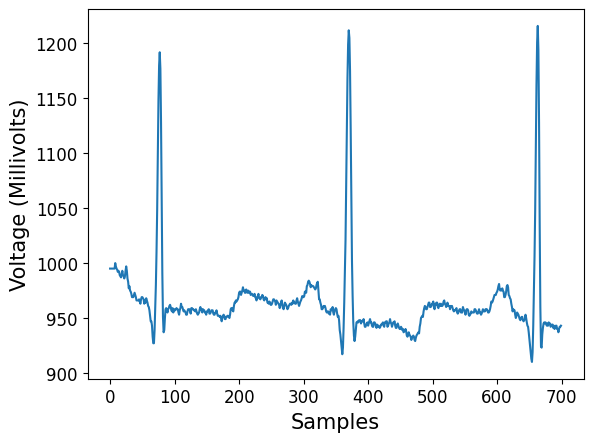

In [ ]:
plt.plot(temp_signal[:700])
plt.xlabel('Samples', fontsize=15)
plt.ylabel('Voltage (Millivolts)', fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig('before_preprocessing')

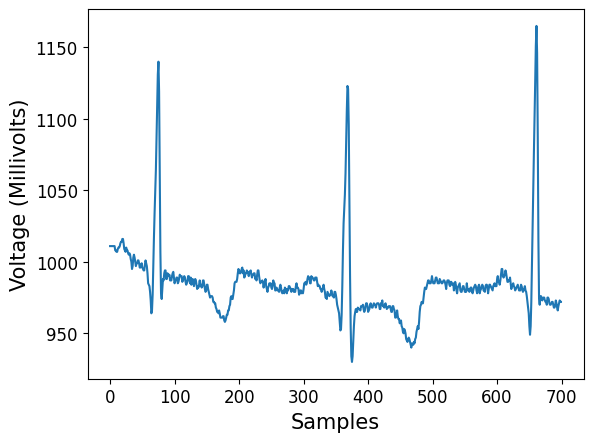

In [ ]:
plt.plot(temp_signal_2[:700])
plt.xlabel('Samples', fontsize=15)
plt.ylabel('Voltage (Millivolts)', fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig('before_preprocessing')

In [ ]:

X1 = []  # sinais completos do canal 1
# X2 = []  # sinais completos do canal 2

patient_ids = []

for r in range(len(records)):
    signals_1 = []
    # signals_2 = []  # canal 2

    with open(records[r], 'r') as csvfile:
        spamreader = csv.reader(csvfile, delimiter=',', quotechar='|')
        row_index = -1
        for row in spamreader:
            if row_index >= 0:
                signals_1.append(int(row[1]))  # segunda coluna (canal 1)
                # signals_2.append(int(row[2]))  # terceira coluna (canal 2)
            row_index += 1

    filename = os.path.basename(records[r])
    patient_number = int(re.findall(r'\d+', filename)[0])

    X1.append(signals_1)
    # X2.append(signals_2)  # ativar se usar canal 2

    patient_ids.append(patient_number)


X1 = np.array(X1, dtype=object)
# X2 = np.array(X2, dtype=object)  # ativar se usar canal 2

patient_ids = np.array(patient_ids)

print(X1.shape, patient_ids.shape)
# print(X2.shape)  # ativar se usar canal 2


(48, 650000) (48,)


In [ ]:

folder_path = '/content/drive/MyDrive/mitbih_database/'
signal_length = 650000  # número total de amostras por paciente

# Lista de arquivos 'annotations.txt'
txt_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('annotations.txt')]
txt_files.sort()


n_patients = len(txt_files)
picos = np.zeros((n_patients, signal_length), dtype=int)            # 1 onde há pico, 0 caso contrário
labels = np.full((n_patients, signal_length), '', dtype='<U2')

for idx, file_path in enumerate(txt_files):
    with open(file_path, 'r') as f:
        next(f)  # pula o cabeçalho
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 3 and parts[1].isdigit():
                peak = int(parts[1])  # posição do pico
                label = parts[2]      # tipo de batimento

                if peak < signal_length:
                    picos[idx, peak] = 1
                    labels[idx, peak] = label

print(f'Formato do vetor de picos: {picos.shape}')
print(f'Formato do vetor de labels: {labels.shape}')
print(f'Exemplo de picos do paciente 0: {np.nonzero(picos[0])[0][:10]}')
print(f'Labels nesses picos: {labels[0][picos[0] == 1][:10]}')





Formato do vetor de picos: (48, 650000)
Formato do vetor de labels: (48, 650000)
Exemplo de picos do paciente 0: [  18   77  370  662  946 1231 1515 1809 2044 2402]
Labels nesses picos: ['+' 'N' 'N' 'N' 'N' 'N' 'N' 'N' 'A' 'N']


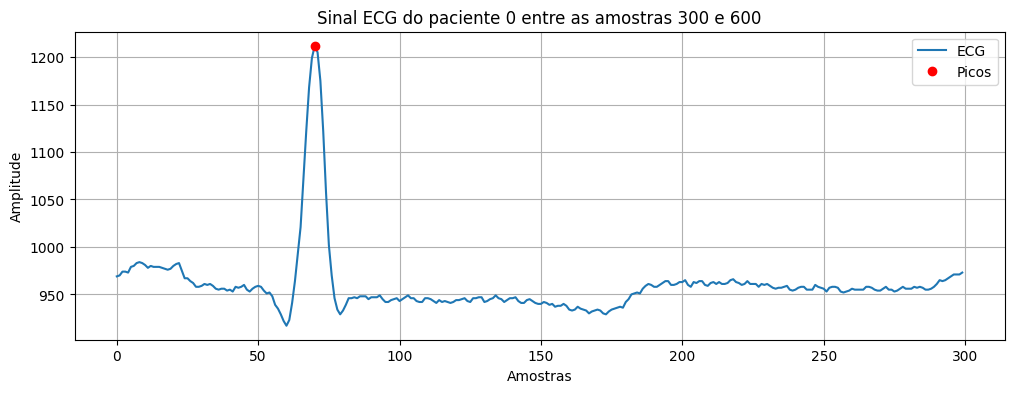

In [ ]:
# ECG do paciente 0
ecg = X1[0]

# Índices dos picos
picos_grafico = np.nonzero(picos[0])[0]


inicio = 300
fim = 600

# Recorte do sinal
ecg_janela = ecg[inicio:fim]


picos_janela = picos_grafico[(picos_grafico >= inicio) & (picos_grafico < fim)] - inicio


plt.figure(figsize=(12, 4))
plt.plot(ecg_janela, label='ECG')
plt.plot(picos_janela, ecg_janela[picos_janela], 'ro', label='Picos')
plt.title(f'Sinal ECG do paciente 0 entre as amostras {inicio} e {fim}')
plt.xlabel('Amostras')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()


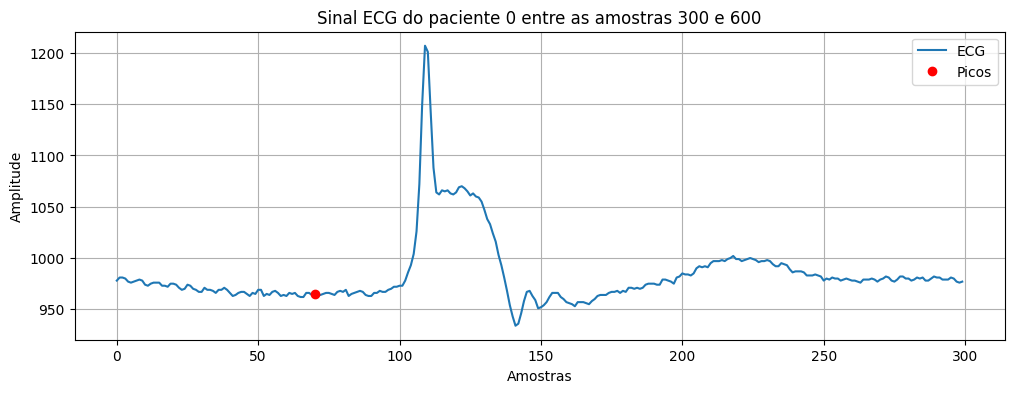

In [ ]:
#exemplo de pico fora
# ECG do paciente 3
ecg = X1[2]

# Índices dos picos
picos_grafico = np.nonzero(picos[0])[0]


inicio = 300
fim = 600

# Recorte do sinal
ecg_janela = ecg[inicio:fim]


picos_janela = picos_grafico[(picos_grafico >= inicio) & (picos_grafico < fim)] - inicio


plt.figure(figsize=(12, 4))
plt.plot(ecg_janela, label='ECG')
plt.plot(picos_janela, ecg_janela[picos_janela], 'ro', label='Picos')
plt.title(f'Sinal ECG do paciente 0 entre as amostras {inicio} e {fim}')
plt.xlabel('Amostras')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

## Filtragem e normalização

In [ ]:
from scipy.signal import butter, filtfilt


def denoise(data):
    w = pywt.Wavelet('sym4')
    maxlev = pywt.dwt_max_level(len(data), w.dec_len)
    threshold = 0.04

    coeffs = pywt.wavedec(data, 'sym4', level=maxlev)
    for i in range(1, len(coeffs)):
        coeffs[i] = pywt.threshold(coeffs[i], threshold*max(coeffs[i]))

    datarec = pywt.waverec(coeffs, 'sym4')


    return datarec


X1_filtrado=denoise(X1[0])







def remove_dc(signal, fs, cutoff=0.2, order=1):

    nyquist = 0.5 * 360
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    filtered_signal = filtfilt(b, a, signal)
    return filtered_signal

X1_filtrado=remove_dc(X1_filtrado, fs = 360)




In [ ]:
from scipy.signal import butter, filtfilt, savgol_filter

def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = filtfilt(b, a, data)
    return y

def filtro_ecg_butter_savgol(signal, fs=360):

    filtered = butter_bandpass_filter(signal, lowcut=0.5, highcut=30, fs=fs, order=4)


    smoothed = savgol_filter(filtered, window_length=11, polyorder=3)

    return smoothed


X1_filtrado2 = filtro_ecg_butter_savgol(X1, fs=360)


In [ ]:
X1_filtrado2_n = (X1_filtrado2 - np.mean(X1_filtrado2)) / np.std(X1_filtrado2)


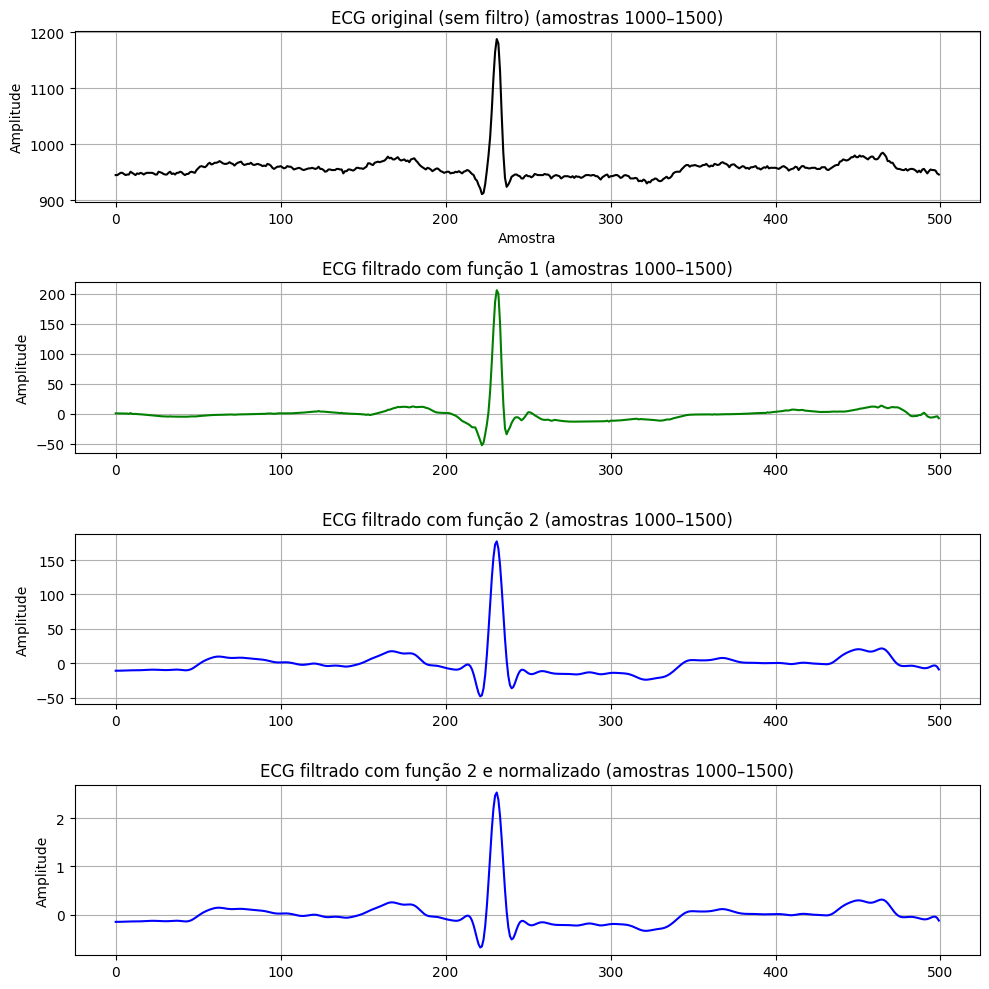

In [ ]:

start = 1000
end = 1500

plt.figure(figsize=(10, 10))

# 4. ECG original (sem filtro)
plt.subplot(4, 1, 1)
plt.plot(X1[0][start:end], color='k')
plt.title(f"ECG original (sem filtro) (amostras {start}–{end})")
plt.xlabel("Amostra")
plt.ylabel("Amplitude")
plt.grid(True)

# 2. ECG filtrado com função 1
plt.subplot(4, 1, 2)
plt.plot(X1_filtrado[start:end], color='g')
plt.title(f"ECG filtrado com função 1 (amostras {start}–{end})")
plt.ylabel("Amplitude")
plt.grid(True)

# 3. ECG filtrado com função 2
plt.subplot(4, 1, 3)
plt.plot(X1_filtrado2[0][start:end], color='b')
plt.title(f"ECG filtrado com função 2 (amostras {start}–{end})")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(X1_filtrado2_n[0][start:end], color='b')
plt.title(f"ECG filtrado com função 2 e normalizado (amostras {start}–{end})")
plt.ylabel("Amplitude")
plt.grid(True)



plt.tight_layout()
plt.show()


##Detecção dos picos RR

In [ ]:
from scipy.signal import find_peaks
import numpy as np

picos_binarios = []

for i in range(len(X1_filtrado2_n)):
    sinal = X1_filtrado2_n[i]
    sinal_mod = np.abs(sinal)

    # Ajusta limiar e distância para detectar menos picos falsos
    peaks, _ = find_peaks(sinal_mod,
                          height=np.mean(sinal_mod) + 0.7*np.std(sinal_mod),
                          distance=150)

    vetor_picos = np.zeros(len(sinal))
    vetor_picos[peaks] = 1
    picos_binarios.append(vetor_picos)

picos_binarios = np.array(picos_binarios)



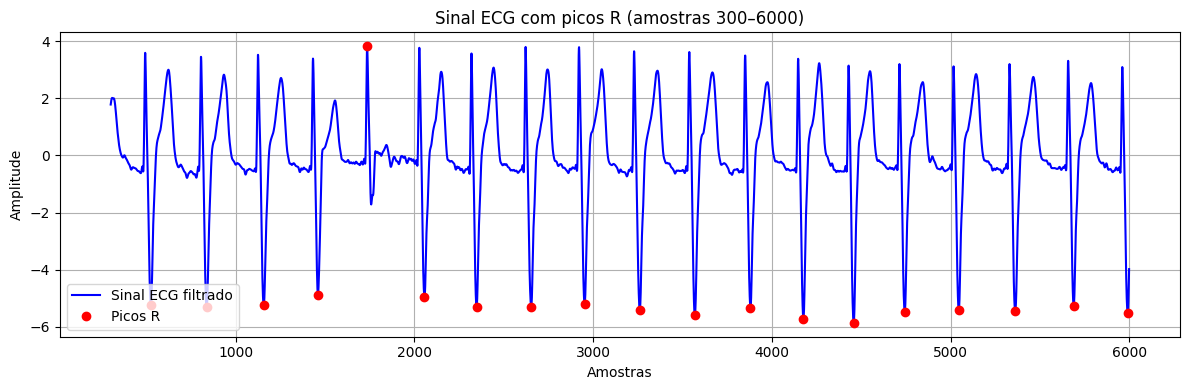

In [ ]:
i = 36

inicio = 300
fim = 6000


sinal_grafico = X1_filtrado2_n[i][inicio:fim]

picos_grafico = picos_binarios[i][inicio:fim]


indices_picos = np.where(picos_grafico == 1)[0]


plt.figure(figsize=(12, 4))
plt.plot(range(inicio, fim), sinal_grafico, label='Sinal ECG filtrado', color='blue')
plt.plot(indices_picos + inicio, sinal_grafico[indices_picos], 'ro', label='Picos R')  # Ajusta para posição global

plt.title(f'Sinal ECG com picos R (amostras {inicio}–{fim})')
plt.xlabel('Amostras')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Extração das features

In [ ]:


rr_data = []

for i in range(len(X1_filtrado2_n)):
    patient_id = patient_ids[i]

    rpeaks = np.where(picos_binarios[i] == 1)[0]

    for j in range(len(rpeaks)):
        rr_prev = None if j == 0 else rpeaks[j] - rpeaks[j - 1]
        rr_next = None if j == len(rpeaks) - 1 else rpeaks[j + 1] - rpeaks[j]

        rr_data.append({
            "paciente_id": patient_id,
            "rpeak_index": rpeaks[j],
            "RR_prev": rr_prev,
            "RR_next": rr_next
        })


df_rr = pd.DataFrame(rr_data)


print(df_rr.head(15))


    paciente_id  rpeak_index  RR_prev  RR_next
0           100           76      NaN    294.0
1           100          370    294.0    292.0
2           100          662    292.0    284.0
3           100          946    284.0    285.0
4           100         1231    285.0    284.0
5           100         1515    284.0    294.0
6           100         1809    294.0    235.0
7           100         2044    235.0    358.0
8           100         2402    358.0    304.0
9           100         2706    304.0    291.0
10          100         2997    291.0    285.0
11          100         3282    285.0    277.0
12          100         3559    277.0    303.0
13          100         3862    303.0    308.0
14          100         4170    308.0    295.0


In [ ]:
df_rr

,paciente_id,rpeak_index,RR_prev,RR_next,RR_local_avg,RR_global_avg
0,100,76,NaN,294.0,NaN,NaN
1,100,370,294.0,292.0,NaN,NaN
2,100,662,292.0,284.0,294.000000,294.000000
3,100,946,284.0,285.0,293.000000,293.000000
4,100,1231,285.0,284.0,290.000000,290.000000
...,...,...,...,...,...,...
108700,234,649040,243.0,252.0,241.846154,240.116071
108701,234,649292,252.0,244.0,241.538462,240.107143
108702,234,649536,244.0,236.0,242.307692,240.138393
108703,234,649772,236.0,221.0,242.769231,240.140625


In [ ]:
import pandas as pd
import numpy as np

sampling_rate = 360
local_time_window = 10 * sampling_rate      # 10 segundos em amostras
global_time_window = 5 * 60 * sampling_rate # 5 minutos em amostras

local_avg_list = []
global_avg_list = []

for i in range(len(X1_filtrado2_n)):
    patient_id = patient_ids[i]
    rpeaks = np.where(picos_binarios[i] == 1)[0]

    for j in range(len(rpeaks)):
        rpeak_current = rpeaks[j]


        idxs_within_10s = [k for k in range(j) if (rpeak_current - rpeaks[k]) <= local_time_window]

        if len(idxs_within_10s) >= 2:
            rr_local_candidates = [rpeaks[k] for k in idxs_within_10s]
            rr_local_intervals = np.diff(rr_local_candidates)
            local_avg = rr_local_intervals.mean()
        else:
            local_avg = None


        idxs_within_5min = [k for k in range(j) if (rpeak_current - rpeaks[k]) <= global_time_window]

        if len(idxs_within_5min) >= 2:
            rr_global_candidates = [rpeaks[k] for k in idxs_within_5min]
            rr_global_intervals = np.diff(rr_global_candidates)
            global_avg = rr_global_intervals.mean()
        else:
            global_avg = None

        local_avg_list.append(local_avg)
        global_avg_list.append(global_avg)

# Adiciona ao DataFrame
df_rr["RR_local_avg"] = local_avg_list
df_rr["RR_global_avg"] = global_avg_list


In [ ]:
df_rr[0:15]

,paciente_id,rpeak_index,RR_prev,RR_next,RR_local_avg,RR_global_avg
0,100,76,NaN,294.0,NaN,NaN
1,100,370,294.0,292.0,NaN,NaN
2,100,662,292.0,284.0,294.000000,294.000000
3,100,946,284.0,285.0,293.000000,293.000000
4,100,1231,285.0,284.0,290.000000,290.000000
5,100,1515,284.0,294.0,288.750000,288.750000
6,100,1809,294.0,235.0,287.800000,287.800000
7,100,2044,235.0,358.0,288.833333,288.833333
8,100,2402,358.0,304.0,281.142857,281.142857
9,100,2706,304.0,291.0,290.750000,290.750000


##janelamento do sinal e extração dos 50 pontos

In [ ]:
janela_antes = 90   # amostras antes do pico
janela_depois = 90  # amostras depois do pico

sinais_segmentados = []
info_segmentos = []

for i in range(len(X1_filtrado2_n)):
    sinal = X1_filtrado2_n[i]
    patient_id = patient_ids[i]
    rpeaks = np.where(picos_binarios[i] == 1)[0]

    for rpeak in rpeaks:
        inicio = rpeak - janela_antes
        fim = rpeak + janela_depois

        # Garante que a janela não ultrapasse os limites do sinal
        if inicio >= 0 and fim < len(sinal):
            segmento = sinal[inicio:fim]
            sinais_segmentados.append(segmento)
            info_segmentos.append({
                "paciente_id": patient_id,
                "rpeak_index": rpeak
            })


In [ ]:
print(len(sinais_segmentados))       # número de janelas
   # tamanho da primeira janela (número de amostras)


108681


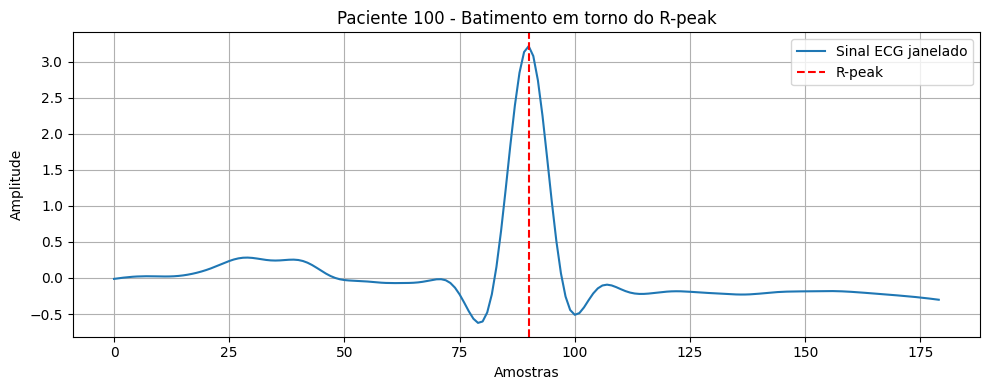

In [ ]:
import matplotlib.pyplot as plt


idx = 0  # por exemplo, a primeira janela

sinal_janela = sinais_segmentados[idx]
rpeak_posicao_relativa = 90

plt.figure(figsize=(10, 4))
plt.plot(sinal_janela, label='Sinal ECG janelado')
plt.axvline(x=rpeak_posicao_relativa, color='red', linestyle='--', label='R-peak')
plt.title(f'Paciente {info_segmentos[idx]["paciente_id"]} - Batimento em torno do R-peak')
plt.xlabel('Amostras')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:


num_pontos = 50  # número de pontos para interpolar cada janela

features = []
pacientes = []
rpeak_indices = []  # para armazenar índice do pico R relativo à janela

for i, janela in enumerate(sinais_segmentados):
    paciente_id = info_segmentos[i]["paciente_id"]
    rpeak_idx = info_segmentos[i]["rpeak_index"]

    # Interpolação para 50 pontos
    if len(janela) < 2:
        janela_interp = [np.nan] * num_pontos
    else:
        x_original = np.linspace(0, len(janela) - 1, len(janela))
        x_novo = np.linspace(0, len(janela) - 1, num_pontos)
        janela_interp = np.interp(x_novo, x_original, janela)

    pacientes.append(paciente_id)
    rpeak_indices.append(rpeak_idx)
    features.append(janela_interp)

# Monta o DataFrame
df_janelas = pd.DataFrame(features, columns=[f'f_{i}' for i in range(num_pontos)])
df_janelas['paciente_id'] = pacientes
df_janelas['rpeak_index'] = rpeak_indices

# Reordena as colunas para paciente_id e rpeak_index ficarem na frente
cols = ['paciente_id', 'rpeak_index'] + [f'f_{i}' for i in range(num_pontos)]
df_janelas = df_janelas[cols]

df_janelas


,paciente_id,rpeak_index,f_0,f_1,f_2,f_3,f_4,f_5,f_6,f_7,...,f_40,f_41,f_42,f_43,f_44,f_45,f_46,f_47,f_48,f_49
0,100,370,-0.012717,0.014728,0.023842,0.020748,0.032928,0.077515,0.155226,0.247217,...,-0.189178,-0.185386,-0.182058,-0.183344,-0.195234,-0.212659,-0.231007,-0.250830,-0.273586,-0.301825
1,100,662,-0.026347,-0.022265,-0.005520,-0.005149,-0.000042,0.057403,0.143639,0.221186,...,-0.214732,-0.236275,-0.229086,-0.212807,-0.195832,-0.173567,-0.168543,-0.194763,-0.224353,-0.239288
2,100,946,-0.080773,-0.079767,-0.066907,-0.033819,0.029291,0.096121,0.153288,0.201733,...,-0.150053,-0.145187,-0.141907,-0.141429,-0.136302,-0.129609,-0.129568,-0.135139,-0.136874,-0.128809
3,100,1231,-0.061979,-0.037189,-0.002113,0.050040,0.107349,0.155721,0.211953,0.251943,...,-0.184352,-0.204782,-0.223829,-0.206789,-0.193775,-0.199245,-0.208684,-0.238296,-0.291867,-0.333381
4,100,1515,-0.005103,-0.013521,-0.010186,0.051012,0.148527,0.223250,0.274204,0.294986,...,-0.248312,-0.225257,-0.231197,-0.259108,-0.268671,-0.248604,-0.225367,-0.230292,-0.261866,-0.299467
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108650,234,648797,-0.072036,-0.084905,-0.073445,-0.041093,-0.051081,-0.082921,-0.095887,-0.083587,...,-0.397855,-0.373401,-0.327371,-0.296010,-0.247829,-0.176603,-0.136028,-0.124510,-0.105185,-0.103406
108651,234,649040,-0.121289,-0.117140,-0.080494,-0.079305,-0.097161,-0.105987,-0.106296,-0.052620,...,-0.408532,-0.388775,-0.347794,-0.319547,-0.262112,-0.224840,-0.236534,-0.207527,-0.130829,-0.088935
108652,234,649292,-0.079943,-0.075942,-0.057203,-0.086441,-0.102479,-0.074049,-0.068567,-0.051101,...,-0.453992,-0.391514,-0.369423,-0.381652,-0.314463,-0.226666,-0.210158,-0.215644,-0.219024,-0.237882
108653,234,649536,-0.202102,-0.191444,-0.220155,-0.243026,-0.246476,-0.260561,-0.254890,-0.196813,...,-0.470134,-0.437507,-0.416363,-0.368975,-0.327652,-0.301074,-0.249512,-0.208947,-0.213711,-0.205113


In [ ]:
# df_rr: DataFrame com RR_prev, RR_next, RR_local_avg, RR_global_avg,
# df_janelas: DataFrame com paciente_id, rpeak_index e as features f_0 a f_49

df_completo = pd.merge(df_rr, df_janelas, on=['paciente_id', 'rpeak_index'], how='inner')



print(df_completo)


        paciente_id  rpeak_index  RR_prev  RR_next  RR_local_avg  \
0               100          370    294.0    292.0           NaN   
1               100          662    292.0    284.0    294.000000   
2               100          946    284.0    285.0    293.000000   
3               100         1231    285.0    284.0    290.000000   
4               100         1515    284.0    294.0    288.750000   
...             ...          ...      ...      ...           ...   
108650          234       648797    241.0    243.0    242.000000   
108651          234       649040    243.0    252.0    241.846154   
108652          234       649292    252.0    244.0    241.538462   
108653          234       649536    244.0    236.0    242.307692   
108654          234       649772    236.0    221.0    242.769231   

        RR_global_avg       f_0       f_1       f_2       f_3  ...      f_40  \
0                 NaN -0.012717  0.014728  0.023842  0.020748  ... -0.189178   
1          294.000000 -

In [ ]:
# 1. Montar um dicionário com todos os picos verdadeiros e seus labels por paciente
true_peaks_dict = {}

for i, pid in enumerate(patient_ids):
    peak_positions = np.nonzero(picos[i])[0]
    labels_paciente = labels[i][picos[i] == 1]

    true_peaks_dict[pid] = list(zip(peak_positions, labels_paciente))

# 2. Função para buscar o pico real mais próximo dentro de uma tolerância
def buscar_label_tolerante(row, tolerancia=60):
    pid = row["paciente_id"]
    pos = row["rpeak_index"]

    if pid in true_peaks_dict:
        for real_pos, label in true_peaks_dict[pid]:
            if abs(real_pos - pos) <= tolerancia:
                return label
    return ""  # não encontrou

# 3. Aplicar ao DataFrame
df_completo["label"] = df_completo.apply(lambda row: buscar_label_tolerante(row, tolerancia=60), axis=1)


print(df_completo.head())


   paciente_id  rpeak_index  RR_prev  RR_next  RR_local_avg  RR_global_avg  \
0          100          370    294.0    292.0           NaN            NaN   
1          100          662    292.0    284.0        294.00         294.00   
2          100          946    284.0    285.0        293.00         293.00   
3          100         1231    285.0    284.0        290.00         290.00   
4          100         1515    284.0    294.0        288.75         288.75   

        f_0       f_1       f_2       f_3  ...      f_41      f_42      f_43  \
0 -0.012717  0.014728  0.023842  0.020748  ... -0.185386 -0.182058 -0.183344   
1 -0.026347 -0.022265 -0.005520 -0.005149  ... -0.236275 -0.229086 -0.212807   
2 -0.080773 -0.079767 -0.066907 -0.033819  ... -0.145187 -0.141907 -0.141429   
3 -0.061979 -0.037189 -0.002113  0.050040  ... -0.204782 -0.223829 -0.206789   
4 -0.005103 -0.013521 -0.010186  0.051012  ... -0.225257 -0.231197 -0.259108   

       f_44      f_45      f_46      f_47      f_4

In [ ]:
df_completo.shape

(108655, 57)

## excluindo os primeiros 5 minutos do sinal e NaNs

In [ ]:
fs = 360  # frequência de amostragem
tempo_limite_amostras = 5 * 60 * fs  # 5 minutos em amostras


df_completo = df_completo.groupby("paciente_id").filter(
    lambda grupo: grupo["rpeak_index"].max() > tempo_limite_amostras
)

df_completo = df_completo[df_completo["rpeak_index"] >= tempo_limite_amostras]

In [ ]:
num_linhas_com_nan = df_completo.isna().any(axis=1).sum()
print(f"Número de linhas com pelo menos um NaN: {num_linhas_com_nan}")


Número de linhas com pelo menos um NaN: 0


In [ ]:
df_completo = df_completo.dropna()


In [ ]:
num_linhas_com_nan = df_completo.isna().any(axis=1).sum()
print(f"Número de linhas com pelo menos um NaN: {num_linhas_com_nan}")

Número de linhas com pelo menos um NaN: 0


#Df completo ------------------------------------------

In [ ]:
df_completo

,paciente_id,rpeak_index,RR_prev,RR_next,RR_local_avg,RR_global_avg,f_0,f_1,f_2,f_3,...,f_41,f_42,f_43,f_44,f_45,f_46,f_47,f_48,f_49,label
370,100,108045,294.0,297.0,292.7,292.1,-0.035356,-0.056552,-0.034588,0.039485,...,-0.220269,-0.232925,-0.239849,-0.238730,-0.242359,-0.246215,-0.245812,-0.255335,-0.280530,N
371,100,108342,297.0,301.0,293.5,292.7,-0.027260,-0.003686,0.041021,0.113042,...,-0.213471,-0.198334,-0.198562,-0.208452,-0.215768,-0.220274,-0.221948,-0.216279,-0.216653,N
372,100,108643,301.0,282.0,293.6,293.5,-0.029753,-0.041659,-0.040031,-0.001530,...,-0.237158,-0.219554,-0.220876,-0.227206,-0.223780,-0.218975,-0.222250,-0.231138,-0.227778,N
373,100,108925,282.0,274.0,291.0,293.6,0.011368,-0.003021,-0.015747,0.012867,...,-0.238002,-0.202640,-0.188005,-0.207234,-0.234134,-0.244903,-0.244480,-0.272847,-0.317113,N
374,100,109199,274.0,286.0,288.5,291.0,-0.023669,-0.006369,-0.021584,-0.023786,...,-0.214032,-0.197950,-0.202406,-0.215672,-0.229787,-0.252936,-0.284933,-0.317637,-0.350697,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108650,234,648797,241.0,243.0,241.7,241.4,-0.072036,-0.084905,-0.073445,-0.041093,...,-0.373401,-0.327371,-0.296010,-0.247829,-0.176603,-0.136028,-0.124510,-0.105185,-0.103406,N
108651,234,649040,243.0,252.0,241.9,241.7,-0.121289,-0.117140,-0.080494,-0.079305,...,-0.388775,-0.347794,-0.319547,-0.262112,-0.224840,-0.236534,-0.207527,-0.130829,-0.088935,N
108652,234,649292,252.0,244.0,242.0,241.9,-0.079943,-0.075942,-0.057203,-0.086441,...,-0.391514,-0.369423,-0.381652,-0.314463,-0.226666,-0.210158,-0.215644,-0.219024,-0.237882,N
108653,234,649536,244.0,236.0,242.4,242.0,-0.202102,-0.191444,-0.220155,-0.243026,...,-0.437507,-0.416363,-0.368975,-0.327652,-0.301074,-0.249512,-0.208947,-0.213711,-0.205113,N


#Minha proposta

##Nova feature

In [ ]:
def extrair_picos_amplitude(beat):
    if len(beat) != 180:
        return [np.nan] * 4

    p1_amp = np.max(beat[0:41])       # máx no intervalo [0, 40]
    p2_amp = np.min(beat[75:86])      # mín no intervalo [75, 85]
    p3_amp = np.min(beat[95:106])     # mín no intervalo [95, 105]
    p4_amp = np.max(beat[150:180])    # máx no intervalo [150, 179]

    return [p1_amp, p2_amp, p3_amp, p4_amp]



amplitudes_features = []
pacientes = []
rpeak_indices = []

for i, janela in enumerate(sinais_segmentados):
    paciente_id = info_segmentos[i]["paciente_id"]
    rpeak_idx = info_segmentos[i]["rpeak_index"]

    # Interpolar para 180 pontos
    if len(janela) < 2:
        janela_interp = [np.nan] * 180
    else:
        x_original = np.linspace(0, len(janela) - 1, len(janela))
        x_novo = np.linspace(0, len(janela) - 1, 180)
        janela_interp = np.interp(x_novo, x_original, janela)

    amplitudes = extrair_picos_amplitude(janela_interp)
    amplitudes_features.append(amplitudes)
    pacientes.append(paciente_id)
    rpeak_indices.append(rpeak_idx)

# DataFrame com os valores de pico
df_picos = pd.DataFrame(amplitudes_features, columns=['amp_max_0_40', 'amp_min_75_85', 'amp_min_95_105', 'amp_max_150_179'])
df_picos['paciente_id'] = pacientes
df_picos['rpeak_index'] = rpeak_indices

# Organiza colunas
cols = ['paciente_id', 'rpeak_index'] + [col for col in df_picos.columns if col not in ['paciente_id', 'rpeak_index']]
df_picos = df_picos[cols]


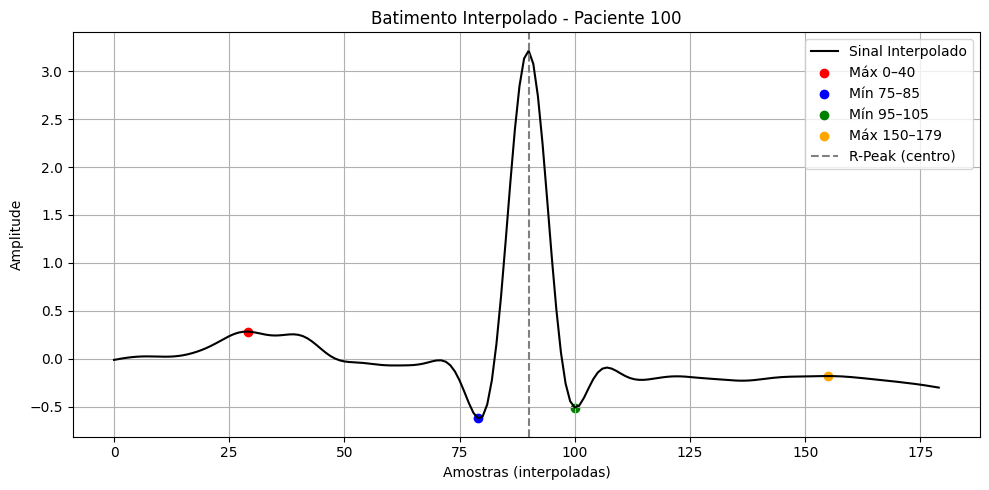

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


i = 0  # exemplo: primeiro batimento
janela = sinais_segmentados[i]


if len(janela) < 2:
    print("Sinal inválido")
else:
    x_original = np.linspace(0, len(janela) - 1, len(janela))
    x_novo = np.linspace(0, len(janela) - 1, 180)
    beat_interp = np.interp(x_novo, x_original, janela)

    # Extrai os picos
    p1_idx = np.argmax(beat_interp[0:41])
    p2_idx = 75 + np.argmin(beat_interp[75:86])
    p3_idx = 95 + np.argmin(beat_interp[95:106])
    p4_idx = 150 + np.argmax(beat_interp[150:180])

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(beat_interp, label='Sinal Interpolado', color='black')
    plt.scatter([p1_idx], [beat_interp[p1_idx]], color='red', label='Máx 0–40')
    plt.scatter([p2_idx], [beat_interp[p2_idx]], color='blue', label='Mín 75–85')
    plt.scatter([p3_idx], [beat_interp[p3_idx]], color='green', label='Mín 95–105')
    plt.scatter([p4_idx], [beat_interp[p4_idx]], color='orange', label='Máx 150–179')

    plt.axvline(90, color='gray', linestyle='--', label='R-Peak (centro)')
    plt.title(f'Batimento Interpolado - Paciente {info_segmentos[i]["paciente_id"]}')
    plt.xlabel('Amostras (interpoladas)')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
# Supondo que df_completo contenha as colunas 'paciente_id' e 'rpeak_index'
df_completo = pd.merge(df_completo, df_picos, on=['paciente_id', 'rpeak_index'], how='left')


In [ ]:
df_completo

,paciente_id,rpeak_index,RR_prev,RR_next,RR_local_avg,RR_global_avg,f_0,f_1,f_2,f_3,...,f_45,f_46,f_47,f_48,f_49,label,amp_max_0_40,amp_min_75_85,amp_min_95_105,amp_max_150_179
0,100,108045,294.0,297.0,292.7,292.1,-0.144719,-0.146537,-0.146274,-0.143318,...,-0.239368,-0.261454,-0.272305,-0.272833,-0.265716,N,0.269818,-0.692165,-0.555982,-0.220578
1,100,108342,297.0,301.0,293.5,292.7,-0.096069,-0.098263,-0.094531,-0.084354,...,-0.210519,-0.237177,-0.254365,-0.261726,-0.261217,N,0.331455,-0.730424,-0.701563,-0.196230
2,100,108643,301.0,282.0,293.6,293.5,-0.124685,-0.132625,-0.134570,-0.128361,...,-0.229523,-0.257746,-0.274656,-0.280843,-0.278872,N,0.303771,-0.763452,-0.566480,-0.217765
3,100,108925,282.0,274.0,291.0,293.6,-0.149836,-0.151638,-0.146007,-0.132250,...,-0.228690,-0.245014,-0.251049,-0.248439,-0.240422,N,0.343034,-0.763056,-0.555752,-0.187796
4,100,109199,274.0,286.0,288.5,291.0,-0.120411,-0.132463,-0.137563,-0.133808,...,-0.199937,-0.225436,-0.240414,-0.245884,-0.244705,N,0.303550,-0.727204,-0.570541,-0.197137
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90548,234,648797,241.0,243.0,241.7,241.4,-0.287276,-0.294344,-0.292794,-0.283553,...,-0.466803,-0.523910,-0.562688,-0.580551,-0.579492,N,0.216032,-0.595079,-0.586509,-0.099276
90549,234,649040,243.0,252.0,241.9,241.7,-0.293330,-0.293158,-0.289420,-0.282618,...,-0.478336,-0.511864,-0.527550,-0.527282,-0.516048,N,0.416897,-0.451491,-0.461353,-0.088935
90550,234,649292,252.0,244.0,242.0,241.9,-0.302323,-0.309707,-0.316029,-0.320671,...,-0.540359,-0.577088,-0.593261,-0.590933,-0.576129,N,0.367740,-0.521188,-0.578492,-0.208631
90551,234,649536,244.0,236.0,242.4,242.0,-0.411416,-0.420533,-0.423270,-0.417913,...,-0.522691,-0.574708,-0.617471,-0.646017,-0.659319,N,0.273227,-0.578077,-0.708227,-0.205113


In [ ]:
df_completo_1= df_completo[df_completo["label"].isin(["N",'V','S','F'])]

##separação de um conjunto de validação e otimização de hiperparâmetros

In [ ]:
pacientes_treino = [101, 114, 115, 116, 118, 119,
 209, 215, 220, 223, 230,213,203, 205, 207, 208,104,107]
pacientes_teste = [100, 103, 105, 111, 113, 117, 121, 123, 200, 202,
210, 212, 214, 219, 221, 222, 228, 231, 232,233, 234]
pacientes_val = [102,122, 124, 201,106, 108, 109, 112]







df_treino = df_completo_1[df_completo_1['paciente_id'].isin(pacientes_treino)].copy()
df_teste  = df_completo_1[df_completo_1['paciente_id'].isin(pacientes_teste)].copy()
df_val    = df_completo_1[df_completo_1['paciente_id'].isin(pacientes_val)].copy()

# Verificar os tamanhos
print("Treino:", df_treino.shape)
print("Teste:", df_teste.shape)
print("Val:", df_val.shape)


Treino: (28220, 61)
Teste: (30126, 61)
Val: (8572, 61)


In [ ]:
df_treino['label'] = df_treino['label'].map(lambda x: 0 if x == 'N' else 1).astype(int)
df_teste['label']  = df_teste['label'].map(lambda x: 0 if x == 'N' else 1).astype(int)
df_val['label']    = df_val['label'].map(lambda x: 0 if x == 'N' else 1).astype(int)


In [ ]:
print(df_treino['label'].value_counts())
print(df_teste['label'].value_counts())
print(df_val['label'].value_counts())

label
0    25208
1     3012
Name: count, dtype: int64
label
0    27749
1     2377
Name: count, dtype: int64
label
0    8005
1     567
Name: count, dtype: int64


In [ ]:


# TREINO
normais_treino = df_treino[df_treino['label'] == 0].sample(n=3000, random_state=42)
anormais_treino = df_treino[df_treino['label'] == 1].sample(n=3000, random_state=42)
df_treino_balanceado = pd.concat([normais_treino, anormais_treino]).sample(frac=1, random_state=42)

# TESTE
normais_teste = df_teste[df_teste['label'] == 0].sample(n=822, random_state=42)
anormais_teste = df_teste[df_teste['label'] == 1].sample(n=1042, random_state=42)
df_teste_balanceado = pd.concat([normais_teste, anormais_teste]).sample(frac=1, random_state=42)

normais_val = df_val[df_val['label'] == 0].sample(n=500, random_state=42)
anormais_val = df_val[df_val['label'] == 1].sample(n=500, random_state=42)
df_val_balanceado = pd.concat([normais_val, anormais_val]).sample(frac=1, random_state=42)

# Verificação
print("Treino balanceado:")
print(df_treino_balanceado['label'].value_counts())
print("\nTeste balanceado:")
print(df_teste_balanceado['label'].value_counts())
print("\nVal balanceado:")
print(df_val_balanceado['label'].value_counts())


Treino balanceado:
label
0    3000
1    3000
Name: count, dtype: int64

Teste balanceado:
label
1    1042
0     822
Name: count, dtype: int64

Val balanceado:
label
1    500
0    500
Name: count, dtype: int64


#Naive Bayes

In [ ]:
X_train = df_treino_balanceado.drop(columns=['label', 'paciente_id', 'rpeak_index'   ])

y_train = df_treino_balanceado['label']



X_test = df_teste_balanceado.drop(columns=['label', 'paciente_id', 'rpeak_index'   ])

y_test = df_teste_balanceado['label']

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, output_dict=True, target_names=['normal', 'anormal'])

accuracy = report['accuracy']
sensitivity = report['anormal']['recall']
specificity = report['normal']['recall']

print(f"Acurácia: {accuracy:.4f}")
print(f"Sensibilidade: {sensitivity:.4f}")
print(f"Especificidade: {specificity:.4f}")


Acurácia: 0.9329
Sensibilidade: 0.9261
Especificidade: 0.9416


In [ ]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report

# Features e labels
X_train = df_treino_balanceado.drop(columns=['label', 'paciente_id', 'rpeak_index'])
y_train = df_treino_balanceado['label']

X_val = df_val_balanceado.drop(columns=['label', 'paciente_id', 'rpeak_index'])
y_val = df_val_balanceado['label']

X_test = df_teste_balanceado.drop(columns=['label', 'paciente_id', 'rpeak_index'])
y_test = df_teste_balanceado['label']

# Lista de hiperparâmetros a testar
var_smoothing_list = np.logspace(-20, -1, 10)

melhor_score = 0
melhor_modelo = None
melhor_smoothing = None

# Loop de otimização
for vs in var_smoothing_list:
    model = GaussianNB(var_smoothing=vs)
    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)

    report = classification_report(y_val, y_val_pred, output_dict=True, target_names=['normal', 'anormal'])
    val_accuracy = report['accuracy']

    print(f"var_smoothing: {vs:.1e} | Val Acurácia: {val_accuracy:.4f}")

    if val_accuracy > melhor_score:
        melhor_score = val_accuracy
        melhor_modelo = model
        melhor_smoothing = vs

# Avaliação no conjunto de teste final
y_test_pred = melhor_modelo.predict(X_test)
final_report = classification_report(y_test, y_test_pred, output_dict=True, target_names=['normal', 'anormal'])

accuracy = final_report['accuracy']
sensitivity = final_report['anormal']['recall']
specificity = final_report['normal']['recall']

print("\n--- Resultados Finais (Teste) ---")
print(f"Melhor var_smoothing: {melhor_smoothing:.1e}")
print(f"Acurácia: {accuracy:.4f}")
print(f"Sensibilidade (anormal): {sensitivity:.4f}")
print(f"Especificidade (normal): {specificity:.4f}")


var_smoothing: 1.0e-20 | Val Acurácia: 0.9500
var_smoothing: 1.3e-18 | Val Acurácia: 0.9500
var_smoothing: 1.7e-16 | Val Acurácia: 0.9500
var_smoothing: 2.2e-14 | Val Acurácia: 0.9500
var_smoothing: 2.8e-12 | Val Acurácia: 0.9500
var_smoothing: 3.6e-10 | Val Acurácia: 0.9500
var_smoothing: 4.6e-08 | Val Acurácia: 0.9500
var_smoothing: 6.0e-06 | Val Acurácia: 0.9370
var_smoothing: 7.7e-04 | Val Acurácia: 0.6200
var_smoothing: 1.0e-01 | Val Acurácia: 0.8150

--- Resultados Finais (Teste) ---
Melhor var_smoothing: 1.0e-20
Acurácia: 0.9329
Sensibilidade (anormal): 0.9261
Especificidade (normal): 0.9416



--- Modelo Final (Treinado com treino+validação) ---
Acurácia: 0.9421
Sensibilidade (anormal): 0.9280
Especificidade (normal): 0.9599


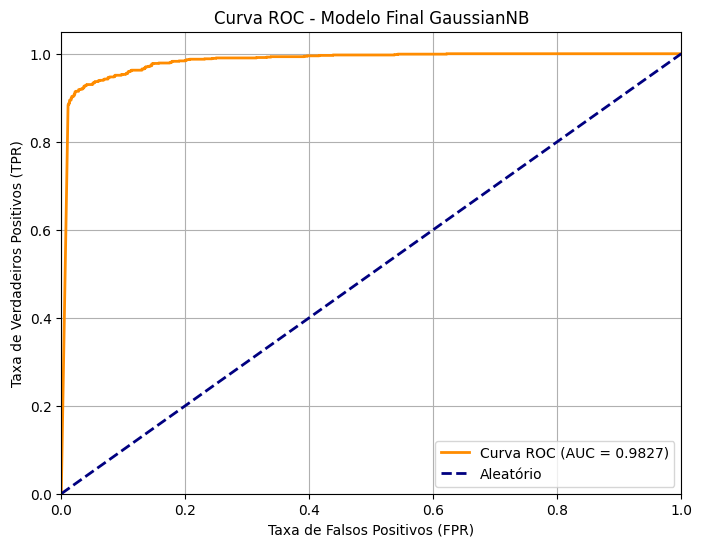

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, roc_curve, auc
import matplotlib.pyplot as plt

# Junta treino e validação
X_treino_final = pd.concat([X_train, X_val], axis=0)
y_treino_final = pd.concat([y_train, y_val], axis=0)

# Treina modelo final com melhor var_smoothing
modelo_final = GaussianNB(var_smoothing=melhor_smoothing)
modelo_final.fit(X_treino_final, y_treino_final)

# Avalia no teste
y_pred_final = modelo_final.predict(X_test)
report_final = classification_report(y_test, y_pred_final, output_dict=True, target_names=['normal', 'anormal'])

accuracy = report_final['accuracy']
sensitivity = report_final['anormal']['recall']
specificity = report_final['normal']['recall']

print("\n--- Modelo Final (Treinado com treino+validação) ---")
print(f"Acurácia: {accuracy:.4f}")
print(f"Sensibilidade (anormal): {sensitivity:.4f}")
print(f"Especificidade (normal): {specificity:.4f}")

# Curva ROC
y_score = modelo_final.predict_proba(X_test)[:, 1]  # Probabilidade da classe "anormal"
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# Plot da curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aleatório')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC - Modelo Final GaussianNB')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


#Decision Tree



In [ ]:
X_train = df_treino_balanceado.drop(columns=['label', 'paciente_id', 'rpeak_index'])
y_train = df_treino_balanceado['label']

X_test = df_teste_balanceado.drop(columns=['label', 'paciente_id', 'rpeak_index'])
y_test = df_teste_balanceado['label']

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

report = classification_report(y_test, y_pred, output_dict=True, target_names=['normal', 'anormal'])

accuracy = report['accuracy']
sensitivity = report['anormal']['recall']
specificity = report['normal']['recall']

print(f"Acurácia: {accuracy:.4f}")
print(f"Sensibilidade: {sensitivity:.4f}")
print(f"Especificidade: {specificity:.4f}")


Acurácia: 0.9281
Sensibilidade: 0.9539
Especificidade: 0.8954


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Dados
X_train = df_treino_balanceado.drop(columns=['label', 'paciente_id', 'rpeak_index'])
y_train = df_treino_balanceado['label']

X_val = df_val_balanceado.drop(columns=['label', 'paciente_id', 'rpeak_index'])
y_val = df_val_balanceado['label']

# Grade de hiperparâmetros
depths = [2,3,5, 10, 15, 20, None]
splits = [2, 10, 20,30,40,50]
leaves = [1, 5, 10,15]
criterions = ['gini', 'entropy']

melhor_score = 0
melhor_modelo = None
melhores_params = {}

for depth in depths:
    for split in splits:
        for leaf in leaves:
            for crit in criterions:
                model = DecisionTreeClassifier(
                    max_depth=depth,
                    min_samples_split=split,
                    min_samples_leaf=leaf,
                    criterion=crit,
                    random_state=42
                )
                model.fit(X_train, y_train)
                y_val_pred = model.predict(X_val)

                report = classification_report(y_val, y_val_pred, output_dict=True, zero_division=0)
                val_accuracy = report['accuracy']

                if val_accuracy > melhor_score:
                    melhor_score = val_accuracy
                    melhor_modelo = model
                    melhores_params = {
                        'max_depth': depth,
                        'min_samples_split': split,
                        'min_samples_leaf': leaf,
                        'criterion': crit
                    }

# Avaliação final no conjunto de teste
X_test = df_teste_balanceado.drop(columns=['label', 'paciente_id', 'rpeak_index'])
y_test = df_teste_balanceado['label']
y_pred = melhor_modelo.predict(X_test)

report = classification_report(y_test, y_pred, output_dict=True, target_names=['normal', 'anormal'])

accuracy = report['accuracy']
sensitivity = report['anormal']['recall']
specificity = report['normal']['recall']

print("--- Melhor modelo encontrado ---")
print(melhores_params)
print("\n--- Desempenho no conjunto de teste ---")
print(f"Acurácia: {accuracy:.4f}")
print(f"Sensibilidade: {sensitivity:.4f}")
print(f"Especificidade: {specificity:.4f}")


--- Melhor modelo encontrado ---
{'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 1, 'criterion': 'gini'}

--- Desempenho no conjunto de teste ---
Acurácia: 0.9415
Sensibilidade: 0.9328
Especificidade: 0.9526


--- Modelo Final (Treinado com treino+validação) ---
{'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 1, 'criterion': 'gini'}
Acurácia: 0.9565
Sensibilidade: 0.9347
Especificidade: 0.9842


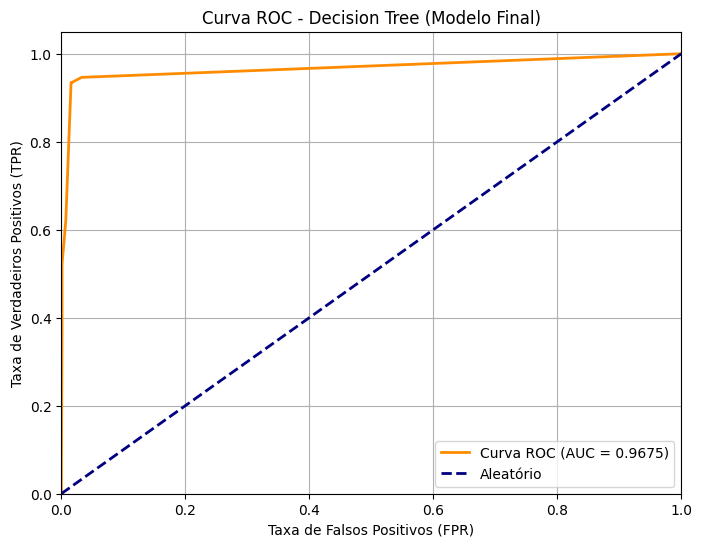

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_curve, auc
import matplotlib.pyplot as plt

# Junta treino e validação para re-treinar o modelo final
X_treino_final = pd.concat([X_train, X_val], axis=0)
y_treino_final = pd.concat([y_train, y_val], axis=0)

# Re-treina com melhores hiperparâmetros
modelo_final = DecisionTreeClassifier(
    max_depth=melhores_params['max_depth'],
    min_samples_split=melhores_params['min_samples_split'],
    min_samples_leaf=melhores_params['min_samples_leaf'],
    criterion=melhores_params['criterion'],
    random_state=42
)
modelo_final.fit(X_treino_final, y_treino_final)

# Avaliação final
y_pred = modelo_final.predict(X_test)

report = classification_report(y_test, y_pred, output_dict=True, target_names=['normal', 'anormal'])
accuracy = report['accuracy']
sensitivity = report['anormal']['recall']
specificity = report['normal']['recall']

print("--- Modelo Final (Treinado com treino+validação) ---")
print(melhores_params)
print(f"Acurácia: {accuracy:.4f}")
print(f"Sensibilidade: {sensitivity:.4f}")
print(f"Especificidade: {specificity:.4f}")

# Curva ROC
y_score = modelo_final.predict_proba(X_test)[:, 1]  # Probabilidade da classe "anormal"
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# Plot da curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aleatório')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC - Decision Tree (Modelo Final)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


#SVM

In [ ]:
X_train = df_treino_balanceado.drop(columns=['label', 'paciente_id', 'rpeak_index'])
y_train = df_treino_balanceado['label']

X_test = df_teste_balanceado.drop(columns=['label', 'paciente_id', 'rpeak_index'])
y_test = df_teste_balanceado['label']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred = svm_model.predict(X_test_scaled)

report = classification_report(y_test, y_pred, output_dict=True, target_names=['normal', 'anormal'])

accuracy = report['accuracy']
sensitivity = report['anormal']['recall']
specificity = report['normal']['recall']

print(f"Acurácia: {accuracy:.4f}")
print(f"Sensibilidade: {sensitivity:.4f}")
print(f"Especificidade: {specificity:.4f}")


Acurácia: 0.9276
Sensibilidade: 0.9184
Especificidade: 0.9392


In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

# Separação das features e labels
X_train = df_treino_balanceado.drop(columns=['label', 'paciente_id', 'rpeak_index'])
y_train = df_treino_balanceado['label']

X_val = df_val_balanceado.drop(columns=['label', 'paciente_id', 'rpeak_index'])
y_val = df_val_balanceado['label']

X_test = df_teste_balanceado.drop(columns=['label', 'paciente_id', 'rpeak_index'])
y_test = df_teste_balanceado['label']

# Grade de hiperparâmetros
C_list = [0.01, 0.1, 1, 10, 100]
gamma_list = ['scale', 'auto', 0.001, 0.01, 0.1, 1]

melhor_score = 0
melhor_modelo = None
melhores_params = {}

# Busca manual pelos melhores hiperparâmetros com validação hold-out
for C in C_list:
    for gamma in gamma_list:
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('svm', SVC(kernel='rbf', C=C, gamma=gamma, random_state=42))
        ])
        pipeline.fit(X_train, y_train)
        y_val_pred = pipeline.predict(X_val)

        report = classification_report(y_val, y_val_pred, output_dict=True, zero_division=0)
        val_accuracy = report['accuracy']

        if val_accuracy > melhor_score:
            melhor_score = val_accuracy
            melhor_modelo = pipeline
            melhores_params = {'C': C, 'gamma': gamma}

# Avaliação final no conjunto de teste
y_test_pred = melhor_modelo.predict(X_test)
report = classification_report(y_test, y_test_pred, output_dict=True, target_names=['normal', 'anormal'])

accuracy = report['accuracy']
sensitivity = report['anormal']['recall']
specificity = report['normal']['recall']

# Resultados
print("--- Melhor modelo encontrado ---")
print(melhores_params)
print("\n--- Desempenho no conjunto de teste ---")
print(f"Acurácia: {accuracy:.4f}")
print(f"Sensibilidade: {sensitivity:.4f}")
print(f"Especificidade: {specificity:.4f}")


--- Melhor modelo encontrado ---
{'C': 0.01, 'gamma': 'scale'}

--- Desempenho no conjunto de teste ---
Acurácia: 0.9410
Sensibilidade: 0.9386
Especificidade: 0.9440


C = 0.01 | gamma = scale
Acurácia: 0.9533
Sensibilidade (anormal): 0.9280
Especificidade (normal): 0.9854


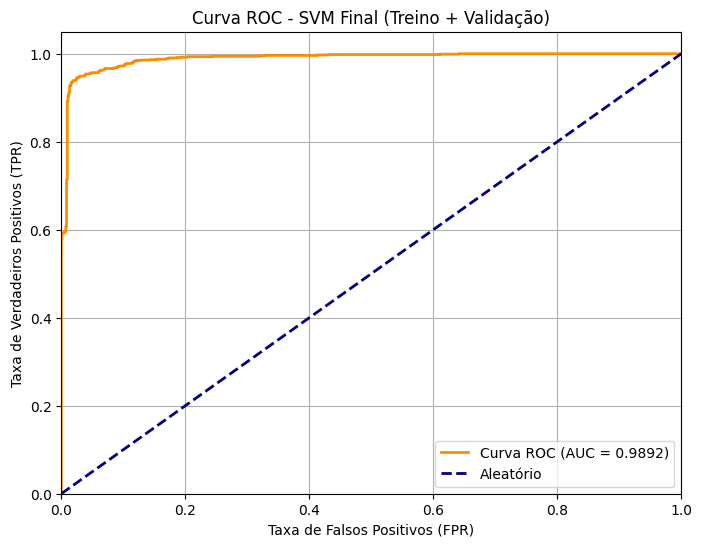

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import pandas as pd

# Hiperparâmetros escolhidos
C_escolhido = 0.01
gamma_escolhido = 'scale'

# Junta treino e validação
X_full_train = pd.concat([X_train, X_val])
y_full_train = pd.concat([y_train, y_val])

# Re-normaliza os dados
scaler = StandardScaler()
X_full_train_scaled = scaler.fit_transform(X_full_train)

# Teste
X_test = df_teste_balanceado.drop(columns=['label', 'paciente_id', 'rpeak_index'])
y_test = df_teste_balanceado['label']
X_test_scaled = scaler.transform(X_test)

# Re-treina modelo com probability=True
modelo_final = SVC(kernel='rbf', C=C_escolhido, gamma=gamma_escolhido, probability=True, random_state=42)
modelo_final.fit(X_full_train_scaled, y_full_train)

# Avaliação
y_pred = modelo_final.predict(X_test_scaled)
report = classification_report(y_test, y_pred, output_dict=True, target_names=['normal', 'anormal'])

accuracy = report['accuracy']
sensitivity = report['anormal']['recall']
specificity = report['normal']['recall']

print(f"C = {C_escolhido} | gamma = {gamma_escolhido}")
print(f"Acurácia: {accuracy:.4f}")
print(f"Sensibilidade (anormal): {sensitivity:.4f}")
print(f"Especificidade (normal): {specificity:.4f}")

# Curva ROC
y_score = modelo_final.predict_proba(X_test_scaled)[:, 1]  # Prob da classe "anormal"
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# Plot da curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', lw=2, label='Aleatório')
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC - SVM Final (Treino + Validação)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


#DNN


In [ ]:


features_50 = [f'f_{i}' for i in range(50)]
other_features = [	'RR_prev',	'RR_next'	,'RR_local_avg'	,'RR_global_avg','amp_max_0_40'	,'amp_min_75_85'	,'amp_min_95_105'	,'amp_max_150_179']
features =  other_features + features_50

X_train = df_treino_balanceado[features].values
y_train = df_treino_balanceado['label'].values

X_val = df_val_balanceado[features].values
y_val = df_val_balanceado['label'].values

X_test = df_teste_balanceado[features].values
y_test = df_teste_balanceado['label'].values

model = models.Sequential([
    layers.Input(shape=(len(features),)),
    layers.Dense(5, activation='relu'),
    layers.Dense(10, activation='relu'),
    layers.Dense(30, activation='relu'),
    layers.Dense(50, activation='relu'),
    layers.Dense(30, activation='relu'),
    layers.Dense(10, activation='relu'),
    layers.Dense(5, activation='relu'),
    layers.Dense(2, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train,
                    epochs=25,
                    batch_size=32,
                    validation_data=(X_val, y_val),
                    shuffle=True)

y_pred_probs = model.predict(X_test)
y_pred = y_pred_probs.argmax(axis=1)

report = classification_report(y_test, y_pred, output_dict=True, target_names=['normal', 'anormal'])

accuracy = report['accuracy']
sensitivity = report['anormal']['recall']
specificity = report['normal']['recall']

print(f"Acurácia: {accuracy:.4f}")
print(f"Sensibilidade: {sensitivity:.4f}")
print(f"Especificidade: {specificity:.4f}")


Epoch 1/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6288 - loss: 0.6547 - val_accuracy: 0.8190 - val_loss: 0.5529
Epoch 2/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8393 - loss: 0.4938 - val_accuracy: 0.8480 - val_loss: 0.4520
Epoch 3/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8809 - loss: 0.4039 - val_accuracy: 0.8660 - val_loss: 0.3957
Epoch 4/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8965 - loss: 0.3404 - val_accuracy: 0.8740 - val_loss: 0.3581
Epoch 5/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9177 - loss: 0.2822 - val_accuracy: 0.8980 - val_loss: 0.2987
Epoch 6/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9175 - loss: 0.2673 - val_accuracy: 0.9080 - val_loss: 0.2846
Epoch 7/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9267 - loss: 0.2460 - val_accuracy: 0.9020 - val_loss: 0.2802
Epoch 8/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9320 - loss: 0.2191 - val_accuracy: 0.

In [ ]:
import tensorflow as tf
from tensorflow.keras import models, layers

batch_sizes = [16, 32, 64, 128]
learning_rates = [0.01, 0.001, 0.0005, 0.0001]
melhores_resultados = []

for bs in batch_sizes:
    for lr in learning_rates:
        print(f"TREINANDO: batch_size={bs}, learning_rate={lr}")

        model = models.Sequential([
            layers.Input(shape=(len(features),)),
            layers.Dense(5, activation='relu'),
            layers.Dense(10, activation='relu'),
            layers.Dense(30, activation='relu'),
            layers.Dense(50, activation='relu'),
            layers.Dense(30, activation='relu'),
            layers.Dense(10, activation='relu'),
            layers.Dense(5, activation='relu'),
            layers.Dense(2, activation='softmax')
        ])

        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
        model.compile(optimizer=optimizer,
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

        history = model.fit(X_train, y_train,
                            epochs=25,
                            batch_size=bs,
                            validation_data=(X_val, y_val),
                            verbose=0,
                            shuffle=True)

        val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
        print(f"Validação: acc={val_acc:.4f}")

        melhores_resultados.append({
            'batch_size': bs,
            'learning_rate': lr,
            'val_accuracy': val_acc
        })


melhor_comb = max(melhores_resultados, key=lambda x: x['val_accuracy'])

print("\n Melhor combinação encontrada:")
print(f"Batch size: {melhor_comb['batch_size']}")
print(f"Learning rate: {melhor_comb['learning_rate']}")
print(f"Acurácia de validação: {melhor_comb['val_accuracy']:.4f}")


TREINANDO: batch_size=16, learning_rate=0.01
Validação: acc=0.5000
TREINANDO: batch_size=16, learning_rate=0.001
Validação: acc=0.5000
TREINANDO: batch_size=16, learning_rate=0.0005
Validação: acc=0.9040
TREINANDO: batch_size=16, learning_rate=0.0001
Validação: acc=0.8790
TREINANDO: batch_size=32, learning_rate=0.01
Validação: acc=0.5000
TREINANDO: batch_size=32, learning_rate=0.001
Validação: acc=0.5000
TREINANDO: batch_size=32, learning_rate=0.0005
Validação: acc=0.5000
TREINANDO: batch_size=32, learning_rate=0.0001
Validação: acc=0.5000
TREINANDO: batch_size=64, learning_rate=0.01
Validação: acc=0.5000
TREINANDO: batch_size=64, learning_rate=0.001
Validação: acc=0.9440
TREINANDO: batch_size=64, learning_rate=0.0005
Validação: acc=0.8360
TREINANDO: batch_size=64, learning_rate=0.0001
Validação: acc=0.8120
TREINANDO: batch_size=128, learning_rate=0.01
Validação: acc=0.9220
TREINANDO: batch_size=128, learning_rate=0.001
Validação: acc=0.8860
TREINANDO: batch_size=128, learning_rate=0.0

Epoch 1/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5212 - loss: 3.4253 - val_accuracy: 0.8700 - val_loss: 0.4673
Epoch 2/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7154 - loss: 0.5783 - val_accuracy: 0.8680 - val_loss: 0.4076
Epoch 3/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7458 - loss: 0.5195 - val_accuracy: 0.8640 - val_loss: 0.3803
Epoch 4/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7549 - loss: 0.4930 - val_accuracy: 0.8430 - val_loss: 0.3759
Epoch 5/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7761 - loss: 0.4714 - val_accuracy: 0.8320 - val_loss: 0.3640
Epoch 6/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7985 - loss: 0.4404 - val_accuracy: 0.8130 - val_loss: 0.3634
Epoch 7/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8106 - loss: 0.4216 - val_accuracy: 0.8190 - val_loss: 0.3646
Epoch 8/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8203 - loss: 0.4029 - val_accuracy: 0.8290 - v

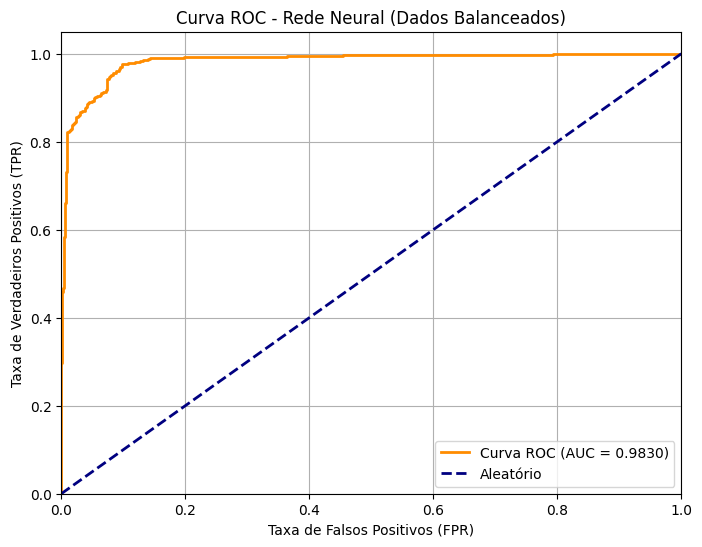

In [ ]:
from tensorflow.keras import models, layers
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Features
features_50 = [f'f_{i}' for i in range(50)]
other_features = [
    'RR_prev', 'RR_next', 'RR_local_avg', 'RR_global_avg',
    'amp_max_0_40', 'amp_min_75_85', 'amp_min_95_105', 'amp_max_150_179'
]
features = other_features + features_50

# Dados
X_train = df_treino_balanceado[features].values
y_train = df_treino_balanceado['label'].values

X_val = df_val_balanceado[features].values
y_val = df_val_balanceado['label'].values

X_test = df_teste_balanceado[features].values
y_test = df_teste_balanceado['label'].values

# Modelo DNN
model = models.Sequential([
    layers.Input(shape=(len(features),)),
    layers.Dense(5, activation='relu'),
    layers.Dense(10, activation='relu'),
    layers.Dense(30, activation='relu'),
    layers.Dense(50, activation='relu'),
    layers.Dense(30, activation='relu'),
    layers.Dense(10, activation='relu'),
    layers.Dense(5, activation='relu'),
    layers.Dense(2, activation='softmax')  # 2 classes
])

model.compile(optimizer=Adam(learning_rate=0.0005),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Treinamento
history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=128,
                    validation_data=(X_val, y_val),
                    shuffle=True)

# Previsão
y_pred_probs = model.predict(X_test)
y_pred = y_pred_probs.argmax(axis=1)

# Avaliação
report = classification_report(y_test, y_pred, output_dict=True, target_names=['normal', 'anormal'])
accuracy = report['accuracy']
sensitivity = report['anormal']['recall']
specificity = report['normal']['recall']

print(f"Acurácia: {accuracy:.4f}")
print(f"Sensibilidade: {sensitivity:.4f}")
print(f"Especificidade: {specificity:.4f}")

# Curva ROC
y_score = y_pred_probs[:, 1]  # Probabilidade da classe "anormal"
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# Plot da curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', lw=2, label='Aleatório')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC - Rede Neural (Dados Balanceados)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


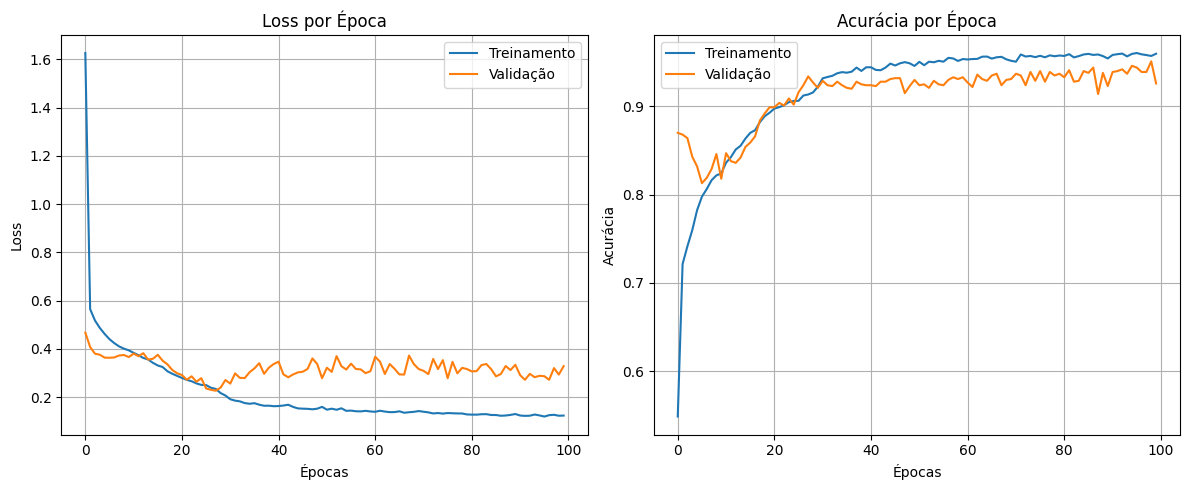

In [ ]:
import matplotlib.pyplot as plt

# Plotando loss (função de custo)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Treinamento')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Loss por Época')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plotando acurácia
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Treinamento')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia por Época')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


#incluindo segundo canal

In [ ]:

X1 = []  # sinais completos do canal 1
X2 = []  # sinais completos do canal 2 (comentado por enquanto)

patient_ids = []

for r in range(len(records)):
    signals_1 = []
    signals_2 = []  # canal 2 comentado

    with open(records[r], 'r') as csvfile:
        spamreader = csv.reader(csvfile, delimiter=',', quotechar='|')
        row_index = -1
        for row in spamreader:
            if row_index >= 0:
                signals_1.append(int(row[1]))  # segunda coluna (canal 1)
                signals_2.append(int(row[2]))  # terceira coluna (canal 2) comentado
            row_index += 1

    filename = os.path.basename(records[r])
    patient_number = int(re.findall(r'\d+', filename)[0])

    X1.append(signals_1)
    X2.append(signals_2)  # ativar se usar canal 2

    patient_ids.append(patient_number)


X1 = np.array(X1, dtype=object)
X2 = np.array(X2, dtype=object)  # ativar se usar canal 2

patient_ids = np.array(patient_ids)

print(X1.shape, patient_ids.shape)
print(X2.shape)  # ativar se usar canal 2


(48, 650000) (48,)
(48, 650000)


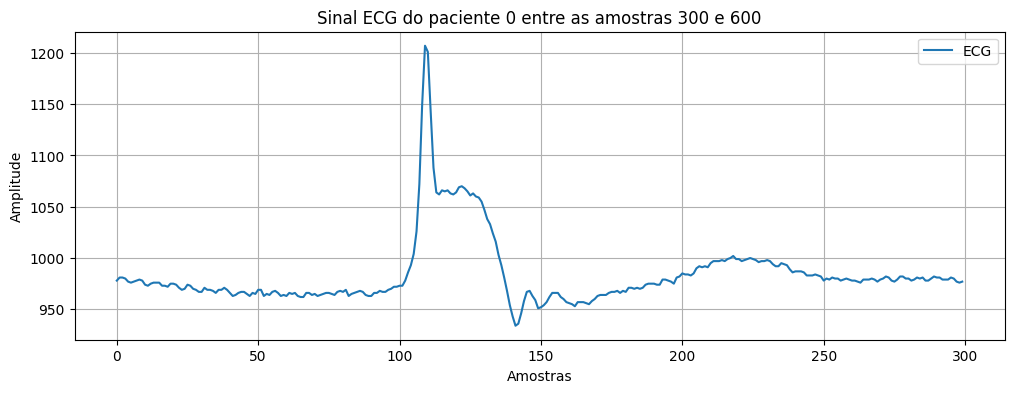

In [ ]:
# ECG do paciente 0
ecg = X1[2]

# Índices dos picos



inicio = 300
fim = 600

# Recorte do sinal
ecg_janela = ecg[inicio:fim]





plt.figure(figsize=(12, 4))
plt.plot(ecg_janela, label='ECG')

plt.title(f'Sinal ECG do paciente 0 entre as amostras {inicio} e {fim}')
plt.xlabel('Amostras')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from scipy.signal import butter, filtfilt, savgol_filter

def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = filtfilt(b, a, data)
    return y

def filtro_ecg_butter_savgol(signal, fs=360):

    filtered = butter_bandpass_filter(signal, lowcut=0.5, highcut=30, fs=fs, order=4)


    smoothed = savgol_filter(filtered, window_length=11, polyorder=3)

    return smoothed


X2_filtrado2 = filtro_ecg_butter_savgol(X2, fs=360)


In [ ]:
X2_filtrado2_n = (X2_filtrado2 - np.mean(X2_filtrado2)) / np.std(X2_filtrado2)


In [ ]:
from scipy.signal import find_peaks
import numpy as np

picos_binarios2 = []

for i in range(len(X2_filtrado2_n)):
    sinal = X2_filtrado2_n[i]
    sinal_mod = np.abs(sinal)

    # Ajusta limiar e distância para detectar menos picos falsos
    peaks, _ = find_peaks(sinal_mod,
                          height=np.mean(sinal_mod) + 0.7*np.std(sinal_mod),
                          distance=150)

    vetor_picos2 = np.zeros(len(sinal))
    vetor_picos2[peaks] = 1
    picos_binarios2.append(vetor_picos2)

picos_binarios2 = np.array(picos_binarios2)



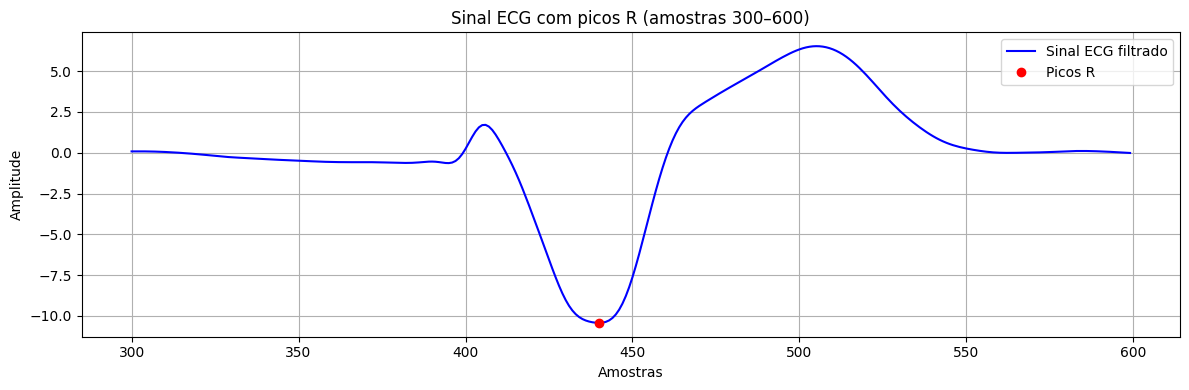

In [ ]:
i = 2


inicio = 300
fim = 600


sinal_grafico = X2_filtrado2_n[i][inicio:fim]

picos_grafico = picos_binarios2[i][inicio:fim]


indices_picos = np.where(picos_grafico == 1)[0]


plt.figure(figsize=(12, 4))
plt.plot(range(inicio, fim), sinal_grafico, label='Sinal ECG filtrado', color='blue')
plt.plot(indices_picos + inicio, sinal_grafico[indices_picos], 'ro', label='Picos R')  # Ajusta para posição global

plt.title(f'Sinal ECG com picos R (amostras {inicio}–{fim})')
plt.xlabel('Amostras')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:


rr_data2 = []

for i in range(len(X2_filtrado2)):
    patient_id = patient_ids[i]

    rpeaks = np.where(picos_binarios2[i] == 1)[0]

    for j in range(len(rpeaks)):
        rr_prev = None if j == 0 else rpeaks[j] - rpeaks[j - 1]
        rr_next = None if j == len(rpeaks) - 1 else rpeaks[j + 1] - rpeaks[j]

        rr_data2.append({
            "paciente_id": patient_id,
            "rpeak_index": rpeaks[j],
            "RR_prev": rr_prev,
            "RR_next": rr_next
        })


df_rr2 = pd.DataFrame(rr_data2)


print(df_rr2.head(15))


    paciente_id  rpeak_index  RR_prev  RR_next
0           100           74      NaN    293.0
1           100          367    293.0    293.0
2           100          660    293.0    284.0
3           100          944    284.0    284.0
4           100         1228    284.0    284.0
5           100         1512    284.0    294.0
6           100         1806    294.0    235.0
7           100         2041    235.0    359.0
8           100         2400    359.0    303.0
9           100         2703    303.0    292.0
10          100         2995    292.0    285.0
11          100         3280    285.0    276.0
12          100         3556    276.0    303.0
13          100         3859    303.0    308.0
14          100         4167    308.0    296.0


In [ ]:
import pandas as pd

local_window = 10  # últimos 10 RR-intervalos
sampling_rate = 360
global_time_window = 5 * 60 * sampling_rate  # 5 minutos em amostras

local_avg_list2 = []
global_avg_list2 = []

for i in range(len(X2_filtrado2)):
    patient_id = patient_ids[i]
    rpeaks = np.where(picos_binarios2[i] == 1)[0]

    rr_intervals = np.diff(rpeaks)

    for j in range(len(rpeaks)):
        # --- Local average RR (últimos 10 intervalos RR) ---
        if j < local_window:
            local_avg = None
        else:
            local_avg = rr_intervals[j - local_window:j].mean()

        # --- Global average RR (últimos 5 minutos) ---
        rpeak_current = rpeaks[j]
        # encontra os picos anteriores dentro dos últimos 5 minutos
        idxs_within_5min = [k for k in range(j) if rpeak_current - rpeaks[k] <= global_time_window]

        if len(idxs_within_5min) >= 2:
            rr_global_intervals = np.diff([rpeaks[k] for k in idxs_within_5min])
            global_avg = rr_global_intervals.mean()
        else:
            global_avg = None

        local_avg_list2.append(local_avg)
        global_avg_list2.append(global_avg)

# Adiciona ao DataFrame
df_rr2["RR_local_avg"] = local_avg_list2
df_rr2["RR_global_avg"] = global_avg_list2


In [ ]:
janela_antes = 90   # amostras antes do pico
janela_depois = 90  # amostras depois do pico

sinais_segmentados2 = []
info_segmentos2 = []

for i in range(len(X2_filtrado2)):
    sinal = X2_filtrado2[i]
    patient_id = patient_ids[i]
    rpeaks = np.where(picos_binarios2[i] == 1)[0]

    for rpeak in rpeaks:
        inicio = rpeak - janela_antes
        fim = rpeak + janela_depois

        # Garante que a janela não ultrapasse os limites do sinal
        if inicio >= 0 and fim < len(sinal):
            segmento = sinal[inicio:fim]
            sinais_segmentados2.append(segmento)
            info_segmentos2.append({
                "paciente_id": patient_id,
                "rpeak_index": rpeak
            })


In [ ]:
print(len(sinais_segmentados2))       # número de janelas
   # tamanho da primeira janela (número de amostras)


105756


In [ ]:


num_pontos = 50  # número de pontos para interpolar cada janela

features = []
pacientes = []
rpeak_indices = []  # para armazenar índice do pico R relativo à janela

for i, janela in enumerate(sinais_segmentados2):
    paciente_id = info_segmentos2[i]["paciente_id"]
    rpeak_idx = info_segmentos2[i]["rpeak_index"]  # supondo que tenha esse dado no dicionário

    # Interpolação para 50 pontos
    if len(janela) < 2:
        janela_interp = [np.nan] * num_pontos
    else:
        x_original = np.linspace(0, len(janela) - 1, len(janela))
        x_novo = np.linspace(0, len(janela) - 1, num_pontos)
        janela_interp = np.interp(x_novo, x_original, janela)

    pacientes.append(paciente_id)
    rpeak_indices.append(rpeak_idx)
    features.append(janela_interp)

# Monta o DataFrame
df_janelas2 = pd.DataFrame(features, columns=[f'f_{i}' for i in range(num_pontos)])
df_janelas2['paciente_id'] = pacientes
df_janelas2['rpeak_index'] = rpeak_indices

# Reordena as colunas para paciente_id e rpeak_index ficarem na frente
cols = ['paciente_id', 'rpeak_index'] + [f'f_{i}' for i in range(num_pontos)]
df_janelas2 = df_janelas2[cols]

df_janelas2


,paciente_id,rpeak_index,f_0,f_1,f_2,f_3,f_4,f_5,f_6,f_7,...,f_40,f_41,f_42,f_43,f_44,f_45,f_46,f_47,f_48,f_49
0,100,367,-0.037903,-0.395520,-0.544252,0.609249,0.091543,-1.591559,-0.022932,4.465282,...,-6.400348,-7.008451,-7.820973,-8.346037,-9.251726,-11.217049,-13.800412,-16.987595,-21.091772,-25.328270
1,100,660,4.352853,4.270602,4.528451,4.620622,4.793922,4.866985,4.924681,5.832329,...,-10.407044,-11.673336,-13.273191,-14.397490,-16.506627,-20.784126,-25.624231,-29.420815,-32.805628,-35.948516
2,100,944,-1.105964,-1.175054,-0.871549,-1.039086,-1.666232,-0.742514,1.757614,3.750800,...,-6.420378,-5.886246,-6.535682,-8.290938,-10.988038,-13.974260,-17.272157,-21.711125,-26.503239,-29.556146
3,100,1228,3.225460,3.244331,2.606430,2.568001,3.015091,3.785664,5.406678,7.162837,...,-6.128633,-5.659794,-6.532076,-6.832239,-7.192573,-9.997723,-14.801176,-19.780501,-23.867017,-27.208637
4,100,1512,-0.913427,-0.722107,-1.135164,-2.117610,-2.932023,-1.646440,1.551390,3.749815,...,-3.801345,-4.941269,-5.992394,-6.247572,-7.427956,-10.770882,-14.483481,-17.182854,-20.362215,-24.064868
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105751,234,648799,1.484764,-0.437950,3.262239,3.661587,2.158584,4.569183,5.859964,4.637995,...,-18.441284,-18.171809,-20.663699,-23.956067,-25.099236,-25.734460,-26.304821,-26.186883,-27.738193,-29.156255
105752,234,649041,3.560273,5.829043,6.745445,4.815186,9.665061,12.889305,6.613795,8.708103,...,-11.359959,-13.333966,-20.293748,-21.658569,-19.744698,-22.955603,-26.198174,-26.318381,-28.209315,-29.436073
105753,234,649294,0.515993,4.549858,4.758349,3.210929,4.855274,5.137071,5.644738,11.880562,...,-17.046461,-21.502284,-22.206038,-19.393183,-21.698280,-27.086617,-27.814100,-27.091699,-28.481966,-26.712796
105754,234,649538,7.815046,9.957684,8.318550,7.304517,7.902750,8.842605,12.502273,18.160974,...,-8.906507,-13.614559,-15.297785,-16.995121,-21.298536,-22.001326,-20.446279,-21.893067,-23.832546,-23.218546


In [ ]:
# df_rr: DataFrame com RR_prev, RR_next, RR_local_avg, RR_global_avg,
# df_janelas: DataFrame com paciente_id, rpeak_index e as features f_0 a f_49

df_completo2 = pd.merge(df_rr2, df_janelas2, on=['paciente_id', 'rpeak_index'], how='inner')



print(df_completo2)


        paciente_id  rpeak_index  RR_prev  RR_next  RR_local_avg  \
0               100          367    293.0    293.0           NaN   
1               100          660    293.0    284.0           NaN   
2               100          944    284.0    284.0           NaN   
3               100         1228    284.0    284.0           NaN   
4               100         1512    284.0    294.0           NaN   
...             ...          ...      ...      ...           ...   
105751          234       648799    240.0    242.0         241.6   
105752          234       649041    242.0    253.0         241.7   
105753          234       649294    253.0    244.0         242.0   
105754          234       649538    244.0    235.0         242.4   
105755          234       649773    235.0    190.0         242.4   

        RR_global_avg       f_0       f_1       f_2       f_3  ...       f_40  \
0                 NaN -0.037903 -0.395520 -0.544252  0.609249  ...  -6.400348   
1          293.000000

In [ ]:
# 1. Montar um dicionário com todos os picos verdadeiros e seus labels por paciente
true_peaks_dict = {}

for i, pid in enumerate(patient_ids):
    peak_positions = np.nonzero(picos[i])[0]
    labels_paciente = labels[i][picos[i] == 1]

    true_peaks_dict[pid] = list(zip(peak_positions, labels_paciente))

# 2. Função para buscar o pico real mais próximo dentro de uma tolerância
def buscar_label_tolerante(row, tolerancia=60):
    pid = row["paciente_id"]
    pos = row["rpeak_index"]

    if pid in true_peaks_dict:
        for real_pos, label in true_peaks_dict[pid]:
            if abs(real_pos - pos) <= tolerancia:
                return label
    return ""  # não encontrou

# 3. Aplicar ao DataFrame
df_completo2["label"] = df_completo2.apply(lambda row: buscar_label_tolerante(row, tolerancia=60), axis=1)


print(df_completo2.head())


   paciente_id  rpeak_index  RR_prev  RR_next  RR_local_avg  RR_global_avg  \
0          100          367    293.0    293.0           NaN            NaN   
1          100          660    293.0    284.0           NaN          293.0   
2          100          944    284.0    284.0           NaN          293.0   
3          100         1228    284.0    284.0           NaN          290.0   
4          100         1512    284.0    294.0           NaN          288.5   

        f_0       f_1       f_2       f_3  ...       f_41       f_42  \
0 -0.037903 -0.395520 -0.544252  0.609249  ...  -7.008451  -7.820973   
1  4.352853  4.270602  4.528451  4.620622  ... -11.673336 -13.273191   
2 -1.105964 -1.175054 -0.871549 -1.039086  ...  -5.886246  -6.535682   
3  3.225460  3.244331  2.606430  2.568001  ...  -5.659794  -6.532076   
4 -0.913427 -0.722107 -1.135164 -2.117610  ...  -4.941269  -5.992394   

        f_43       f_44       f_45       f_46       f_47       f_48  \
0  -8.346037  -9.251726 -11

In [ ]:
num_linhas_com_nan = df_completo2.isna().any(axis=1).sum()
print(f"Número de linhas com pelo menos um NaN: {num_linhas_com_nan}")

Número de linhas com pelo menos um NaN: 484


In [ ]:
df_completo2 = df_completo2.dropna()

In [ ]:
num_linhas_com_nan = df_completo2.isna().any(axis=1).sum()
print(f"Número de linhas com pelo menos um NaN: {num_linhas_com_nan}")

Número de linhas com pelo menos um NaN: 0


In [ ]:
df_completo_2= df_completo2[df_completo2["label"].isin(["N",'V','S','F'])]

In [ ]:
df_completo_2

,paciente_id,rpeak_index,RR_prev,RR_next,RR_local_avg,RR_global_avg,f_0,f_1,f_2,f_3,...,f_41,f_42,f_43,f_44,f_45,f_46,f_47,f_48,f_49,label
9,100,2995,292.0,285.0,292.1,292.111111,0.048734,0.274133,1.121461,1.930264,...,-11.455348,-11.502598,-12.586444,-15.231013,-18.936287,-23.229913,-27.641969,-31.680526,-34.936578,N
10,100,3280,285.0,276.0,291.3,292.100000,0.910533,1.700819,2.312903,2.946254,...,-1.992526,-2.149985,-4.109217,-7.186945,-9.163132,-11.587859,-15.571842,-19.005185,-21.510757,N
11,100,3556,276.0,303.0,289.6,291.454545,-0.808713,0.994991,1.152243,0.684950,...,-9.346611,-9.547042,-10.605770,-12.417890,-13.431900,-14.503267,-17.438642,-21.550854,-26.312303,N
12,100,3859,303.0,308.0,291.5,290.166667,2.741743,2.280444,2.307959,2.210461,...,-6.386513,-7.506165,-9.682517,-11.672860,-12.996365,-15.381864,-19.651446,-24.488212,-28.557882,N
13,100,4167,308.0,296.0,293.9,291.153846,-0.862700,-1.151685,-1.098597,-1.051406,...,-7.592856,-8.730939,-9.478251,-10.483679,-12.492389,-15.065599,-18.189651,-21.575715,-25.211351,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105751,234,648799,240.0,242.0,241.6,240.149554,1.484764,-0.437950,3.262239,3.661587,...,-18.171809,-20.663699,-23.956067,-25.099236,-25.734460,-26.304821,-26.186883,-27.738193,-29.156255,N
105752,234,649041,242.0,253.0,241.7,240.113839,3.560273,5.829043,6.745445,4.815186,...,-13.333966,-20.293748,-21.658569,-19.744698,-22.955603,-26.198174,-26.318381,-28.209315,-29.436073,N
105753,234,649294,253.0,244.0,242.0,240.102679,0.515993,4.549858,4.758349,3.210929,...,-21.502284,-22.206038,-19.393183,-21.698280,-27.086617,-27.814100,-27.091699,-28.481966,-26.712796,N
105754,234,649538,244.0,235.0,242.4,240.136161,7.815046,9.957684,8.318550,7.304517,...,-13.614559,-15.297785,-16.995121,-21.298536,-22.001326,-20.446279,-21.893067,-23.832546,-23.218546,N


In [ ]:
df_2canais = pd.concat([df_completo_1, df_completo_2], ignore_index=True)


In [ ]:
df_2canais

,paciente_id,rpeak_index,RR_prev,RR_next,RR_local_avg,RR_global_avg,f_0,f_1,f_2,f_3,...,f_45,f_46,f_47,f_48,f_49,label,amp_max_0_40,amp_min_75_85,amp_min_95_105,amp_max_150_179
0,100,108045,294.0,297.0,291.454545,291.013514,-0.035356,-0.056552,-0.034588,0.039485,...,-0.242359,-0.246215,-0.245812,-0.255335,-0.280530,N,0.269818,-0.692165,-0.555982,-0.220578
1,100,108342,297.0,301.0,292.272727,291.013514,-0.027260,-0.003686,0.041021,0.113042,...,-0.215768,-0.220274,-0.221948,-0.216279,-0.216653,N,0.331455,-0.730424,-0.701563,-0.196230
2,100,108643,301.0,282.0,293.090909,291.027027,-0.029753,-0.041659,-0.040031,-0.001530,...,-0.223780,-0.218975,-0.222250,-0.231138,-0.227778,N,0.303771,-0.763452,-0.566480,-0.217765
3,100,108925,282.0,274.0,294.181818,291.072973,0.011368,-0.003021,-0.015747,0.012867,...,-0.234134,-0.244903,-0.244480,-0.272847,-0.317113,N,0.343034,-0.763056,-0.555752,-0.187796
4,100,109199,274.0,286.0,292.545455,291.064865,-0.023669,-0.006369,-0.021584,-0.023786,...,-0.229787,-0.252936,-0.284933,-0.317637,-0.350697,N,0.303550,-0.727204,-0.570541,-0.197137
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143898,234,648799,240.0,242.0,241.600000,240.149554,1.484764,-0.437950,3.262239,3.661587,...,-25.734460,-26.304821,-26.186883,-27.738193,-29.156255,N,NaN,NaN,NaN,NaN
143899,234,649041,242.0,253.0,241.700000,240.113839,3.560273,5.829043,6.745445,4.815186,...,-22.955603,-26.198174,-26.318381,-28.209315,-29.436073,N,NaN,NaN,NaN,NaN
143900,234,649294,253.0,244.0,242.000000,240.102679,0.515993,4.549858,4.758349,3.210929,...,-27.086617,-27.814100,-27.091699,-28.481966,-26.712796,N,NaN,NaN,NaN,NaN
143901,234,649538,244.0,235.0,242.400000,240.136161,7.815046,9.957684,8.318550,7.304517,...,-22.001326,-20.446279,-21.893067,-23.832546,-23.218546,N,NaN,NaN,NaN,NaN


In [ ]:
df_treino = df_2canais[df_2canais['paciente_id'].isin(pacientes_treino)].copy()
df_teste  = df_2canais[df_2canais['paciente_id'].isin(pacientes_teste)].copy()
df_val  = df_2canais[df_2canais['paciente_id'].isin(pacientes_val)].copy()


df_treino['label'] = df_treino['label'].apply(lambda x: 0 if x == 'N' else 1)
df_teste['label'] = df_teste['label'].apply(lambda x: 0 if x == 'N' else 1)
df_val['label'] = df_val['label'].apply(lambda x: 0 if x == 'N' else 1)



print(df_treino['label'].value_counts())
print(df_teste['label'].value_counts())
print(df_val['label'].value_counts())









label
0    54182
1     6675
Name: count, dtype: int64
label
0    58303
1     4900
Name: count, dtype: int64
label
0    17818
1     1390
Name: count, dtype: int64


In [ ]:
# TREINO
normais_treino = df_treino[df_treino['label'] == 0].sample(n=3000, random_state=42)
anormais_treino = df_treino[df_treino['label'] == 1].sample(n=3000, random_state=42)
df_treino_2canais = pd.concat([normais_treino, anormais_treino]).sample(frac=1, random_state=42)

# TESTE
normais_teste = df_teste[df_teste['label'] == 0].sample(n=822, random_state=42)
anormais_teste = df_teste[df_teste['label'] == 1].sample(n=1042, random_state=42)
df_teste_2canais = pd.concat([normais_teste, anormais_teste]).sample(frac=1, random_state=42)

normais_val = df_val[df_val['label'] == 0].sample(n=500, random_state=42)
anormais_val = df_val[df_val['label'] == 1].sample(n=500, random_state=42)
df_val_2canais = pd.concat([normais_val, anormais_val]).sample(frac=1, random_state=42)




In [ ]:
X_train = df_treino_2canais.drop(columns=['label', 'paciente_id', 'rpeak_index' ,'amp_max_0_40',	'amp_min_75_85',	'amp_min_95_105',	'amp_max_150_179'  ])

y_train = df_treino_balanceado['label']



X_test = df_teste_2canais.drop(columns=['label', 'paciente_id', 'rpeak_index' ,'amp_max_0_40',	'amp_min_75_85',	'amp_min_95_105',	'amp_max_150_179'  ])

y_test = df_teste_balanceado['label']

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, output_dict=True, target_names=['normal', 'anormal'])

accuracy = report['accuracy']
sensitivity = report['anormal']['recall']
specificity = report['normal']['recall']

print(f"Acurácia: {accuracy:.4f}")
print(f"Sensibilidade: {sensitivity:.4f}")
print(f"Especificidade: {specificity:.4f}")


Acurácia: 0.6583
Sensibilidade: 0.4779
Especificidade: 0.8869


In [ ]:

X_train = df_treino_2canais.drop(columns=['label', 'paciente_id', 'rpeak_index','amp_max_0_40',	'amp_min_75_85',	'amp_min_95_105',	'amp_max_150_179'])
y_train = df_treino_2canais['label']

X_val = df_val_2canais.drop(columns=['label', 'paciente_id', 'rpeak_index','amp_max_0_40',	'amp_min_75_85',	'amp_min_95_105',	'amp_max_150_179'])
y_val = df_val_2canais['label']

X_test = df_teste_2canais.drop(columns=['label', 'paciente_id', 'rpeak_index','amp_max_0_40',	'amp_min_75_85',	'amp_min_95_105',	'amp_max_150_179'])
y_test = df_teste_2canais['label']


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


X_grid = np.vstack([X_train_scaled, X_val_scaled])
y_grid = np.concatenate([y_train, y_val])


val_index = [-1]*len(X_train) + [0]*len(X_val)
ps = PredefinedSplit(test_fold=val_index)


param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.001, 0.0001],
    'kernel': ['rbf']
}


gs = GridSearchCV(SVC(random_state=42), param_grid, cv=ps, refit=True, verbose=1)
gs.fit(X_grid, y_grid)


best_model = gs.best_estimator_


y_pred = best_model.predict(X_test_scaled)
report = classification_report(y_test, y_pred, output_dict=True, target_names=['normal', 'anormal'])

accuracy = report['accuracy']
sensitivity = report['anormal']['recall']
specificity = report['normal']['recall']

# Resultados
print(f"Melhores parâmetros: {gs.best_params_}")
print(f"Acurácia: {accuracy:.4f}")
print(f"Sensibilidade: {sensitivity:.4f}")
print(f"Especificidade: {specificity:.4f}")


Fitting 1 folds for each of 16 candidates, totalling 16 fits
Melhores parâmetros: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Acurácia: 0.8380
Sensibilidade: 0.8148
Especificidade: 0.8674


In [ ]:


features_50 = [f'f_{i}' for i in range(50)]
other_features = ['RR_prev', 'RR_next', 'RR_local_avg', 'RR_global_avg']
features = features_50 + other_features

X_train = df_treino_2canais[features].values
y_train = df_treino_2canais['label'].values

X_val = df_val_2canais[features].values
y_val = df_val_2canais['label'].values

X_test = df_teste_2canais[features].values
y_test = df_teste_2canais['label'].values

model = models.Sequential([
    layers.Input(shape=(len(features),)),
    layers.Dense(5, activation='relu'),
    layers.Dense(10, activation='relu'),
    layers.Dense(30, activation='relu'),
    layers.Dense(50, activation='relu'),
    layers.Dense(30, activation='relu'),
    layers.Dense(10, activation='relu'),
    layers.Dense(5, activation='relu'),
    layers.Dense(2, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train,
                    epochs=25,
                    batch_size=32,
                    validation_data=(X_val, y_val),
                    shuffle=True)

y_pred_probs = model.predict(X_test)
y_pred = y_pred_probs.argmax(axis=1)

report = classification_report(y_test, y_pred, output_dict=True, target_names=['normal', 'anormal'])

accuracy = report['accuracy']
sensitivity = report['anormal']['recall']
specificity = report['normal']['recall']

print(f"Acurácia: {accuracy:.4f}")
print(f"Sensibilidade: {sensitivity:.4f}")
print(f"Especificidade: {specificity:.4f}")


Epoch 1/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4898 - loss: 1.8622 - val_accuracy: 0.4630 - val_loss: 0.7215
Epoch 2/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5231 - loss: 0.6798 - val_accuracy: 0.4490 - val_loss: 0.7701
Epoch 3/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5278 - loss: 0.6774 - val_accuracy: 0.4300 - val_loss: 1.0390
Epoch 4/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6078 - loss: 0.6076 - val_accuracy: 0.5310 - val_loss: 1.4201
Epoch 5/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7325 - loss: 0.4605 - val_accuracy: 0.6670 - val_loss: 1.1922
Epoch 6/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8206 - loss: 0.3946 - val_accuracy: 0.7580 - val_loss: 1.5577
Epoch 7/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8773 - loss: 0.3279 - val_accuracy: 0.7330 - val_loss: 1.1492
Epoch 8/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8920 - loss: 0.2983 - val_accuracy: 0.

#Reproduzindo o artigo proposto---------------------------------

In [ ]:
df_completo_a= df_completo[df_completo["label"].isin(['N','V','S','F'])]

In [ ]:
pacientes_treino = [101, 106, 108, 109, 112, 114, 115, 116, 118, 119,
122, 124, 201, 203, 205, 207, 208, 209, 215, 220, 223, 230]
pacientes_teste = [100, 103, 105, 111, 113, 117, 121, 123, 200, 202,
210, 212, 213, 214, 219, 221, 222, 228, 231, 232,233, 234]






# Criar subconjuntos de treino e teste com base na coluna paciente_id


df_treino = df_completo_a[df_completo_a['paciente_id'].isin(pacientes_treino)].copy()
df_teste  = df_completo_a[df_completo_a['paciente_id'].isin(pacientes_teste)].copy()


# Verificar os tamanhos
print("Treino:", df_treino.shape)
print("Teste:", df_teste.shape)



Treino: (33967, 57)
Teste: (32792, 57)


In [ ]:
df_treino['label'] = df_treino['label'].map(lambda x: 0 if x == 'N' else 1).astype(int)
df_teste['label']  = df_teste['label'].map(lambda x: 0 if x == 'N' else 1).astype(int)



In [ ]:


# TREINO
normais_treino = df_treino[df_treino['label'] == 0].sample(n=1466, random_state=42)
anormais_treino = df_treino[df_treino['label'] == 1].sample(n=1246, random_state=42)
df_treino_a = pd.concat([normais_treino, anormais_treino]).sample(frac=1, random_state=42)

# TESTE
normais_teste = df_teste[df_teste['label'] == 0].sample(n=822, random_state=42)
anormais_teste = df_teste[df_teste['label'] == 1].sample(n=1042, random_state=42)
df_teste_a = pd.concat([normais_teste, anormais_teste]).sample(frac=1, random_state=42)



# Verificação
print("Treino :")
print(df_treino_a['label'].value_counts())
print("\nTeste :")
print(df_teste_a['label'].value_counts())



Treino :
label
0    1466
1    1246
Name: count, dtype: int64

Teste :
label
1    1042
0     822
Name: count, dtype: int64


##Naive Bayes


Acurácia: 0.9329
Sensibilidade: 0.9549
Especificidade: 0.9051


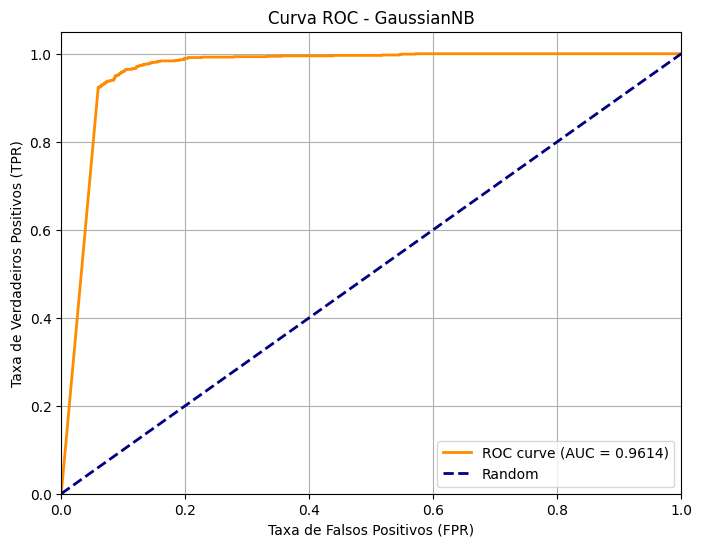

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, roc_curve, auc
import matplotlib.pyplot as plt

# Treinamento
X_train = df_treino_a.drop(columns=['label', 'paciente_id', 'rpeak_index'])
y_train = df_treino_a['label']

X_test = df_teste_a.drop(columns=['label', 'paciente_id', 'rpeak_index'])
y_test = df_teste_a['label']

model = GaussianNB()
model.fit(X_train, y_train)

# Previsão de rótulos
y_pred = model.predict(X_test)

# Relatório de classificação
report = classification_report(y_test, y_pred, output_dict=True, target_names=['normal', 'anormal'])
accuracy = report['accuracy']
sensitivity = report['anormal']['recall']
specificity = report['normal']['recall']

print(f"Acurácia: {accuracy:.4f}")
print(f"Sensibilidade: {sensitivity:.4f}")
print(f"Especificidade: {specificity:.4f}")

# Previsão de probabilidades para a classe positiva (anormal = 1)
y_score = model.predict_proba(X_test)[:, 1]

# Cálculo da curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# Plot da curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC - GaussianNB')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


##Decision Tree


Acurácia: 0.8675
Sensibilidade: 0.9213
Especificidade: 0.7993


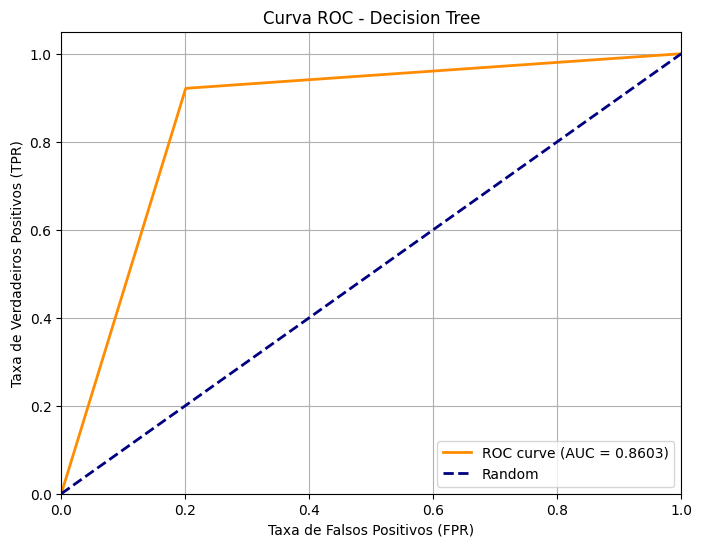

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_curve, auc
import matplotlib.pyplot as plt

# Separação de dados
X_train = df_treino_a.drop(columns=['label', 'paciente_id', 'rpeak_index'])
y_train = df_treino_a['label']

X_test = df_teste_a.drop(columns=['label', 'paciente_id', 'rpeak_index'])
y_test = df_teste_a['label']

# Treinamento do modelo
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Previsão
y_pred = model.predict(X_test)

# Relatório de classificação
report = classification_report(y_test, y_pred, output_dict=True, target_names=['normal', 'anormal'])
accuracy = report['accuracy']
sensitivity = report['anormal']['recall']
specificity = report['normal']['recall']

print(f"Acurácia: {accuracy:.4f}")
print(f"Sensibilidade: {sensitivity:.4f}")
print(f"Especificidade: {specificity:.4f}")

# Previsão de probabilidades para a curva ROC
y_score = model.predict_proba(X_test)[:, 1]

# Cálculo da curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# Plot da curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC - Decision Tree')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


##SVM


Acurácia: 0.9426
Sensibilidade: 0.9645
Especificidade: 0.9148


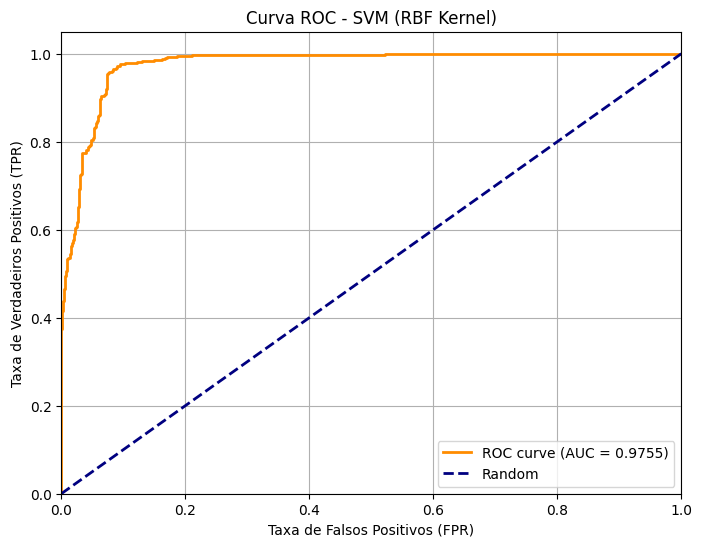

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_curve, auc
import matplotlib.pyplot as plt

# Separação dos dados
X_train = df_treino_a.drop(columns=['label', 'paciente_id', 'rpeak_index'])
y_train = df_treino_a['label']

X_test = df_teste_a.drop(columns=['label', 'paciente_id', 'rpeak_index'])
y_test = df_teste_a['label']

# Escalonamento
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelo SVM com probabilidade habilitada
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Previsão
y_pred = svm_model.predict(X_test_scaled)

# Relatório de classificação
report = classification_report(y_test, y_pred, output_dict=True, target_names=['normal', 'anormal'])
accuracy = report['accuracy']
sensitivity = report['anormal']['recall']
specificity = report['normal']['recall']

print(f"Acurácia: {accuracy:.4f}")
print(f"Sensibilidade: {sensitivity:.4f}")
print(f"Especificidade: {specificity:.4f}")

# Curva ROC
y_score = svm_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# Plot da curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC - SVM (RBF Kernel)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


##DNN

Epoch 1/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5227 - loss: 1.7498
Epoch 2/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8406 - loss: 0.5181
Epoch 3/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8747 - loss: 0.4190
Epoch 4/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8475 - loss: 0.3894
Epoch 5/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8661 - loss: 0.3181
Epoch 6/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8896 - loss: 0.2922
Epoch 7/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8909 - loss: 0.2979
Epoch 8/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8977 - loss: 0.2925
Epoch 9/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9090 - loss: 0.2539
Epoch 10/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9091 - loss: 0.2570
Epoch 11/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9066 - loss: 0.2563
Epoch 12/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9110 - lo

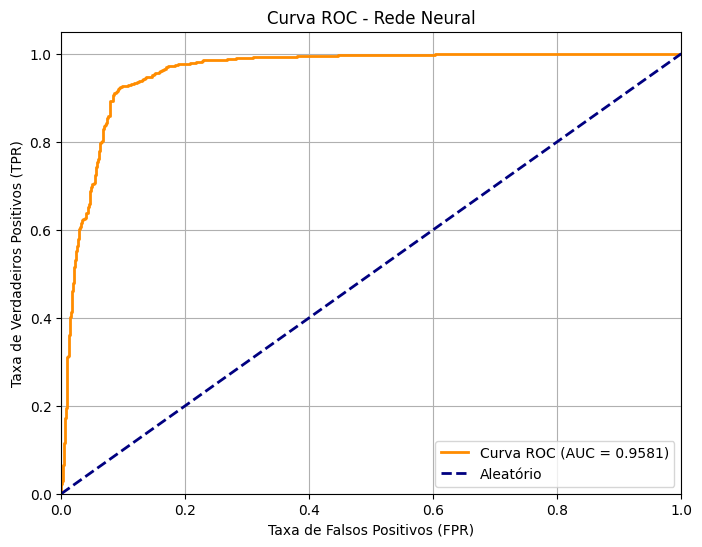

In [ ]:
from tensorflow.keras import models, layers
from sklearn.metrics import classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Definição das features
features_50 = [f'f_{i}' for i in range(50)]
other_features = ['RR_prev', 'RR_next', 'RR_local_avg', 'RR_global_avg']
features = features_50 + other_features

# Separação dos dados
X_train = df_treino_a[features].values
y_train = df_treino_a['label'].values

X_test = df_teste_a[features].values
y_test = df_teste_a['label'].values

# Definição do modelo DNN
model = models.Sequential([
    layers.Input(shape=(len(features),)),
    layers.Dense(5, activation='relu'),
    layers.Dense(10, activation='relu'),
    layers.Dense(30, activation='relu'),
    layers.Dense(50, activation='relu'),
    layers.Dense(30, activation='relu'),
    layers.Dense(10, activation='relu'),
    layers.Dense(5, activation='relu'),
    layers.Dense(2, activation='softmax')  # 2 classes: normal (0), anormal (1)
])

# Compilação
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Treinamento
history = model.fit(X_train, y_train,
                    epochs=25,
                    batch_size=32,
                    shuffle=True)

# Previsões
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Relatório de classificação
report = classification_report(y_test, y_pred, output_dict=True, target_names=['normal', 'anormal'])
accuracy = report['accuracy']
sensitivity = report['anormal']['recall']
specificity = report['normal']['recall']

print(f"Acurácia: {accuracy:.4f}")
print(f"Sensibilidade: {sensitivity:.4f}")
print(f"Especificidade: {specificity:.4f}")

# Curva ROC
y_score = y_pred_probs[:, 1]  # Probabilidades da classe 'anormal'
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# Plot da curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aleatório')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC - Rede Neural')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
